# Constructing EOS and solving TOV equations beyond General Relativity

This example notebook shows how to construct the equation of state with the metamodel and speed-of-sound extension scheme parametrization used in the paper, as well as solve the TOV equations beyond GR. 

In [1]:
import matplotlib.pyplot as plt
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
params = {"text.usetex" : True,
          "font.family" : "serif",
          "font.serif" : ["Computer Modern Serif"],
          "xtick.labelsize": 16,
          "ytick.labelsize": 16,
          "axes.labelsize": 16,
          "legend.fontsize": 16,
          "legend.title_fontsize": 16}
plt.rcParams.update(params)
import jax.numpy as jnp
import jax
from jax import config
config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
# from jesterTOV.eos.metamodel.metamodel_CSE import MetaModel_with_CSE_EOS_model
# from jesterTOV.eos.families import construct_family, construct_family_nonGR, construct_family_ST, construct_family_ST_Greci, construct_family_ST_sol, construct_family_eibi
import jesterTOV.utils as utils
import time
from jesterTOV import utils
from jesterTOV.eos.metamodel import MetaModel_EOS_model, MetaModel_with_CSE_EOS_model
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.scalar_tensor import ScalarTensorTOVSolver
# from jesterTOV.tov.eibi import EiBITOVSolver
from jesterTOV.tov.data_classes import EOSData

# Equation of state

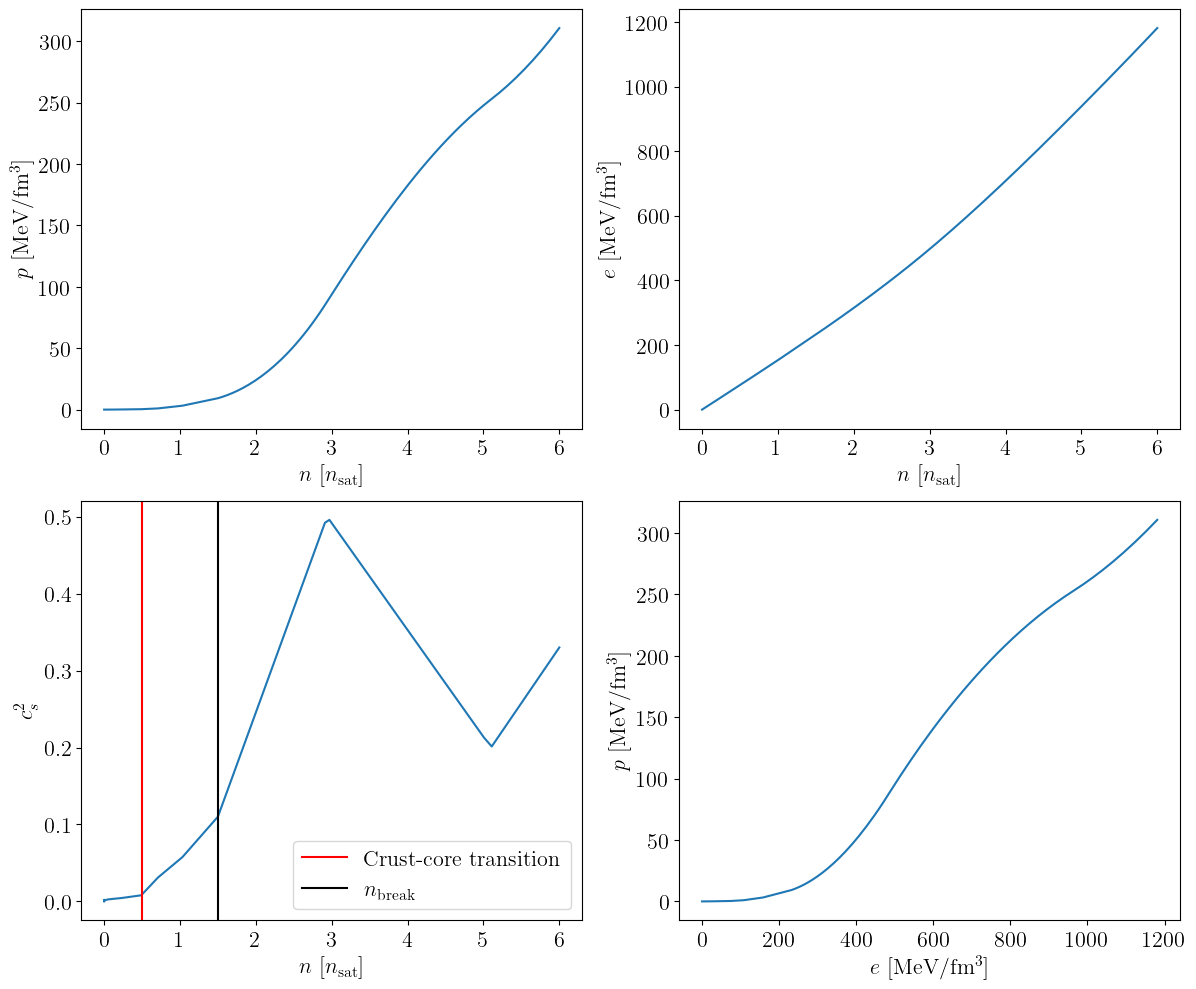

In [2]:
nsat = 0.16 # nuclear saturation density in fm^-3

# Define the EOS object, here we focus on Metamodel with CSE
nmax_nsat = 6.0
nb_CSE=4
eos = MetaModel_with_CSE_EOS_model(nmax_nsat=nmax_nsat, nb_CSE=nb_CSE, nmin_MM_nsat=0.75,ndat_metamodel=80, ndat_CSE=70)
#crust_name = "SLy"
# Define the nuclear empirical parameters (NEPs) -- all in MeV
input_dict = {"E_sat": -16.0, # saturation parameters
            "K_sat": 200.0,
            "Q_sat": 0.0,
            "Z_sat": 0.0,
            "E_sym": 32.0, # symmetry parameters
            "L_sym": 70.0,
            "K_sym": -100.0,
            "Q_sym": 0.0,
            "Z_sym": 0.0,
            "nbreak": 1.5 * nsat,
            }


# Then we extend with some CSE grid points
ngrids = jnp.array([2.0, 3.0, 4.0, 5.0]) * nsat
cs2grids = jnp.array([0.5, 0.4, 0.3, 0.2]) # speed of sound squared at the grid points
# Add CSE grid parameters (normalized positions and cs2 values)
input_dict["n_CSE_0_u"] = ngrids[0]
input_dict["cs2_CSE_0"] = cs2grids[0]
input_dict["n_CSE_1_u"] = ngrids[1]
input_dict["cs2_CSE_1"] = cs2grids[1]
input_dict["n_CSE_2_u"] = ngrids[2]
input_dict["cs2_CSE_2"] = cs2grids[2]
input_dict["n_CSE_3_u"] = ngrids[3]
input_dict["cs2_CSE_3"] = cs2grids[3]
input_dict["n_CSE_4_u"] = nmax_nsat
input_dict["cs2_CSE_4"] = 0.33  # Final cs2 value

# Now create the EOS -- returns a tuple with most useful EOS quantities
eos_output= eos.construct_eos(input_dict)
ns, ps, hs, es, dloge_dlogps, mu, cs2 =  eos_output.ns, eos_output.ps, eos_output.hs, eos_output.es, eos_output.dloge_dlogps, eos_output.mu, eos_output.cs2

# Make a plot
plt.subplots(nrows = 2, ncols = 2, figsize = (12, 10))

# For the plot, let's make some conversions to more common units
ns_plots = ns / utils.fm_inv3_to_geometric / 0.16
es_plots = es / utils.MeV_fm_inv3_to_geometric
ps_plots = ps / utils.MeV_fm_inv3_to_geometric

# p(n)
plt.subplot(221)
plt.plot(ns_plots, ps_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")

# e(n)
plt.subplot(222)
plt.plot(ns_plots, es_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$e$ [MeV/fm$^3$]")

# cs2(n)
plt.subplot(223)
plt.plot(ns_plots, cs2)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$c_s^2$")
plt.axvline(0.5, color = "red", label = "Crust-core transition")
plt.axvline(input_dict["nbreak"] / nsat, color = "black", label = r"$n_{\rm{break}}$")
plt.legend()

# p(e)
plt.subplot(224)
plt.plot(es_plots, ps_plots)
plt.xlabel(r"$e$ [MeV/fm$^3$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")
plt.tight_layout()
plt.show() # uncomment to see the EOS
plt.close()

# 1. Neutron stars in Standard Scalar-Tensor Theory

##### Solving the TOV equations to construct an M(R) curve and calculate their tidal deformabilities based on Gastón Creci, Tanja Hinderer, Jan Steinhoff Phys.Rev.D 108 (2023) 12, 124073

In [3]:
import jax.numpy as jnp                                                                                                    
import jax                                                                                                               
import matplotlib.pyplot as plt                                                                                            
import time                                                                                                                

from jesterTOV import utils
from jesterTOV.tov.data_classes import EOSData
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.scalar_tensor import ScalarTensorTOVSolver


Running vmap for scalar-tensor calculations...
Scalar-tensor calculations for 8 beta values finished in 88.7134 seconds.


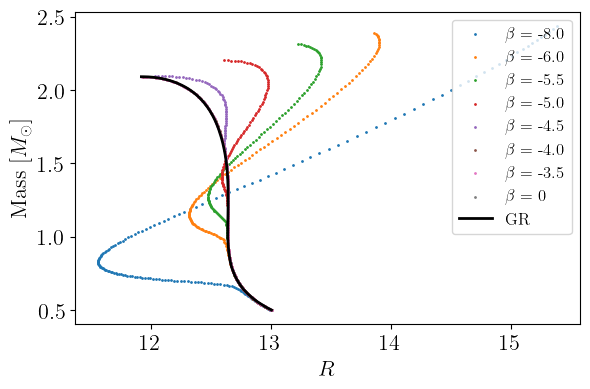

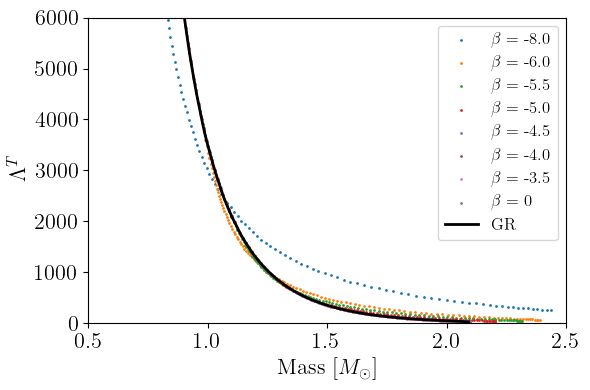

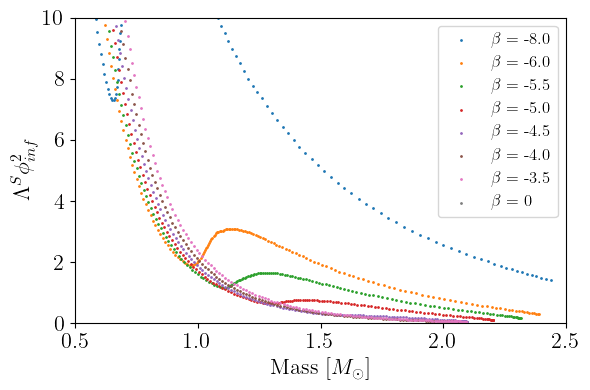

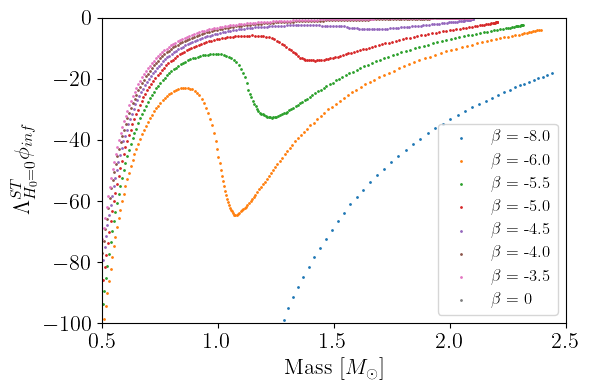

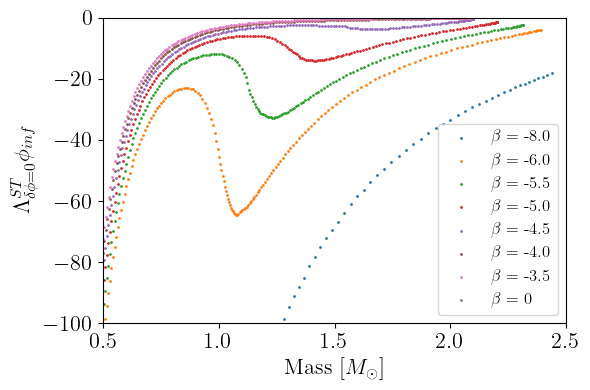

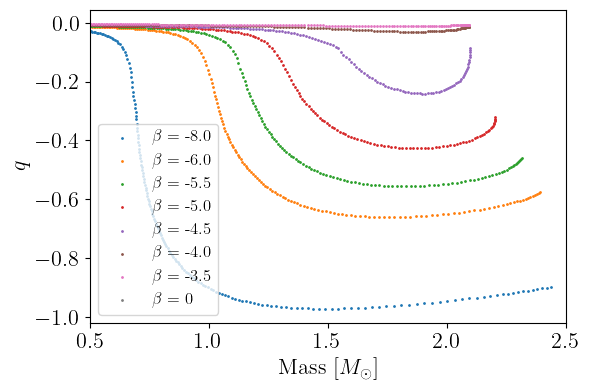

In [4]:

# Parameters
beta_values = [-8.0,-6.0, -5.5, -5.0, -4.5, -4.0, -3.5, 0]
# beta_values = jnp.linspace(0, -9, 1000)
# beta_values = [-7.0]
phi_c = 1.0
phi_inf_tgt = 1e-3

# Create EOSData (assuming ns, ps, hs, es, dloge_dlogps, cs2 are defined)
eos_data = EOSData(
  ns=ns,
  ps=ps,
  hs=hs,
  es=es,
  dloge_dlogps=dloge_dlogps,
  cs2=cs2,
)

# Create solvers
gr_solver = GRTOVSolver()
st_solver = ScalarTensorTOVSolver()

print("Running vmap for scalar-tensor calculations...")

def solve_for_beta(beta_ST):
    tov_params = {
        "beta_ST": beta_ST,
        "phi_c": phi_c,
        "phi_inf_tgt": phi_inf_tgt
    }
    family = st_solver.construct_family(
      eos_data,
      ndat=300,
      min_nsat=0.1,
      tov_params=tov_params
    )
    return family

beta_array = jnp.array(beta_values)

start_time = time.time()
solve_for_beta_vmapped = jax.vmap(solve_for_beta)
st_families = solve_for_beta_vmapped(beta_array)

st_masses = st_families.masses
st_radii = st_families.radii
st_lambdas = st_families.lambdas
st_extra = st_families.extra  # Dictionary with solver-specific fields

st_masses.block_until_ready()
end_time = time.time()
duration = end_time - start_time
print(f"Scalar-tensor calculations for {len(beta_values)} beta values finished in {duration:.4f} seconds.")

# Collect results - filter out NaN values
results = {}
r_max = 50  # km
for i, beta_ST in enumerate(beta_values):
    radii_km = st_radii[i]
    masses_solar = st_masses[i]
    lambdas = st_lambdas[i]
    
    # Access extra fields from the dict
    mask = (radii_km < r_max) & (radii_km > 5) & (masses_solar > 0.5) & jnp.isfinite(st_extra["lambda_S"][i])
    
    results[beta_ST] = {
      "masses": masses_solar[mask],
      "radii": radii_km[mask],
      "lambdas": lambdas[mask],
      "lambdas_S": st_extra["lambda_S"][i][mask],
      "lambdas_ST1": st_extra["lambda_ST1"][i][mask],
      "lambdas_ST2": st_extra["lambda_ST2"][i][mask],
      "qs": st_extra["q"][i][mask],
    }

# GR reference
gr_family = gr_solver.construct_family(eos_data, ndat=300, min_nsat=0.5, tov_params={})
gr_mask = (gr_family.radii < r_max) & (gr_family.radii > 5) & (gr_family.masses > 0.5)
gr_masses = gr_family.masses[gr_mask]
gr_lambdas = gr_family.lambdas[gr_mask]
gr_radii = gr_family.radii[gr_mask]

plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter( data["radii"], data["masses"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot( gr_radii, gr_masses,label='GR', color='black', linewidth=2)
plt.ylabel(r"Mass [$M_\odot$]")
plt.xlabel(r"$R$")
# plt.ylim(0, 6000)
# plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 1: Tensor tidal deformability Λ^T vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot(gr_masses, gr_lambdas, label='GR', color='black', linewidth=2)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^T$")
plt.ylim(0, 6000)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 2: Scalar tidal deformability Λ^S * φ_inf^2 vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_S"] * phi_inf_tgt**2, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^S \phi_{inf}^2$")
plt.ylim(0, 10)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 3: Mixed tidal deformability Λ^ST1 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST1"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{H_0 = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 4: Mixed tidal deformability Λ^ST2 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST2"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{\delta \phi = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 5: Scalar charge q vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
  plt.scatter(data["masses"], data["qs"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$q$")
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()


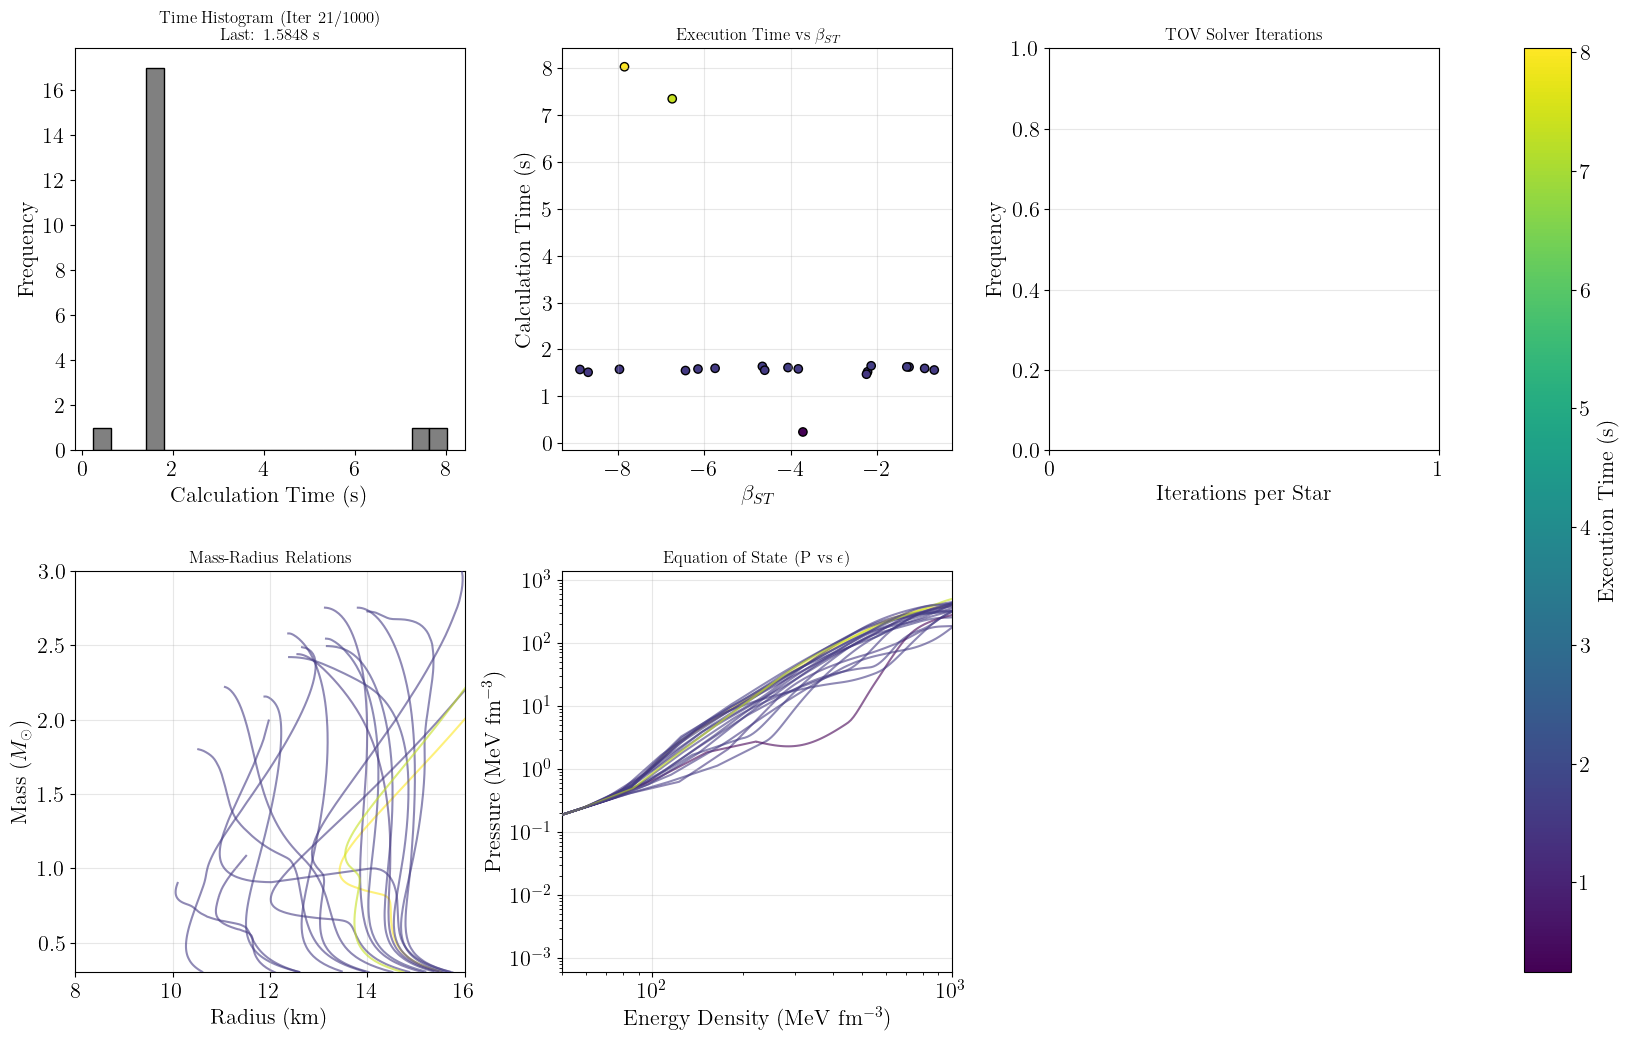


KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x705752497ec0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

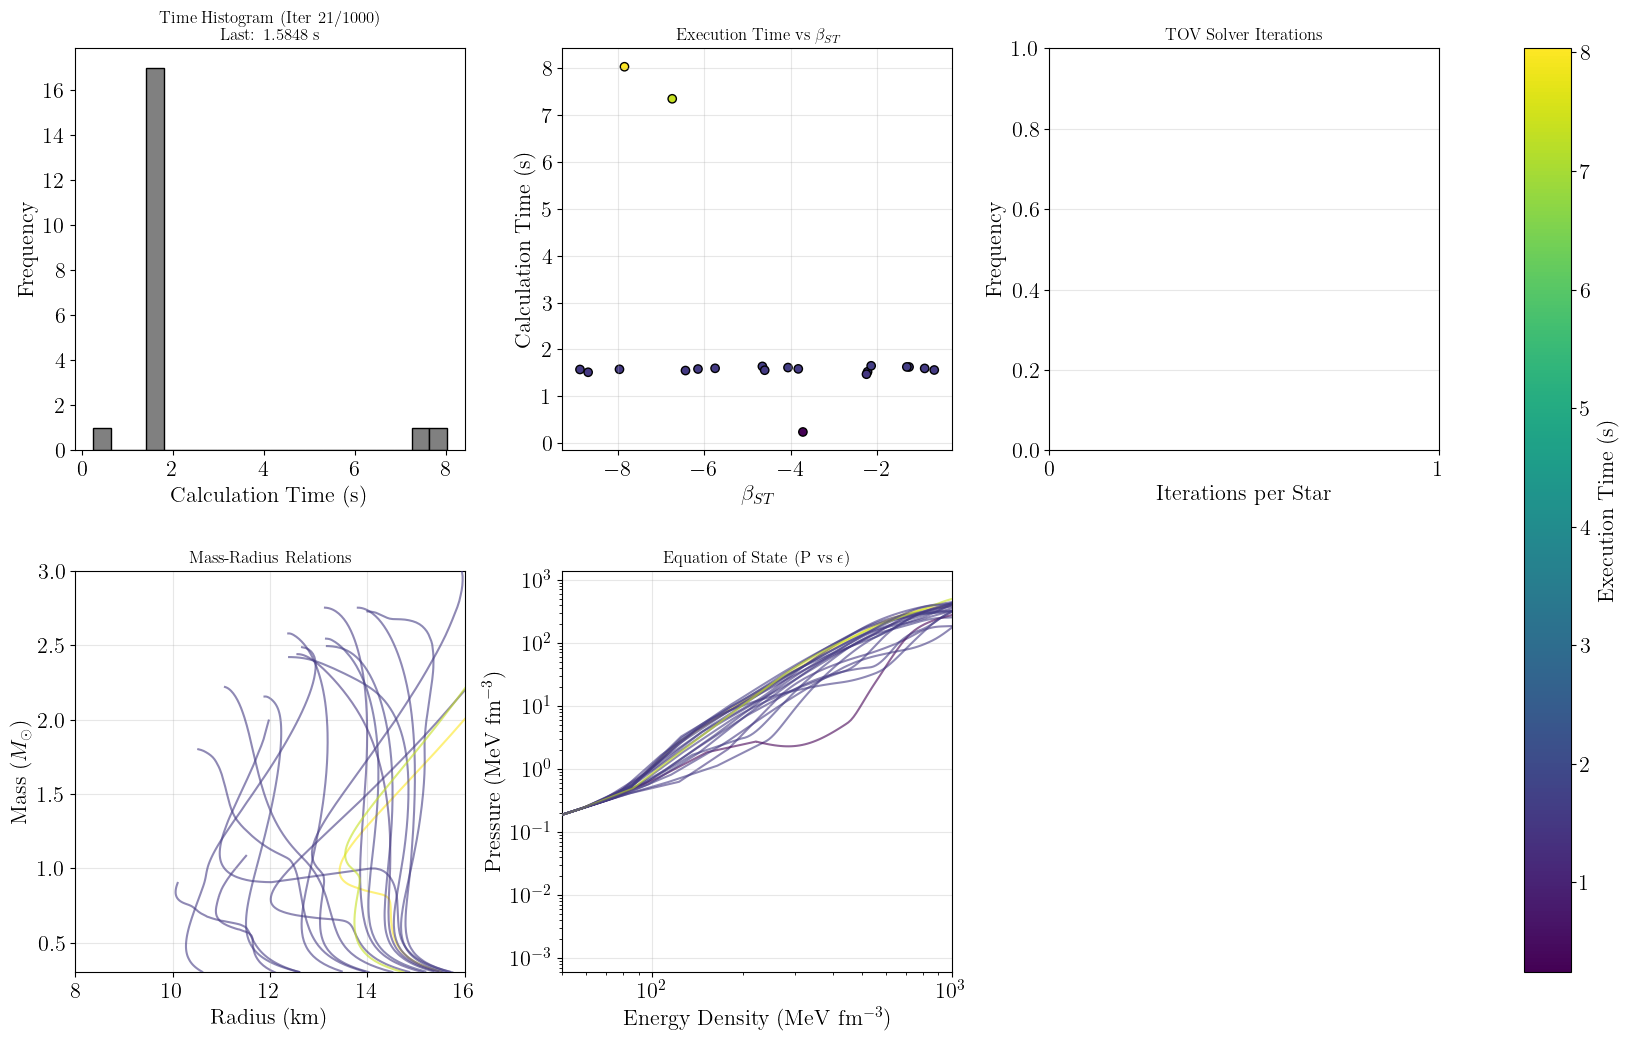

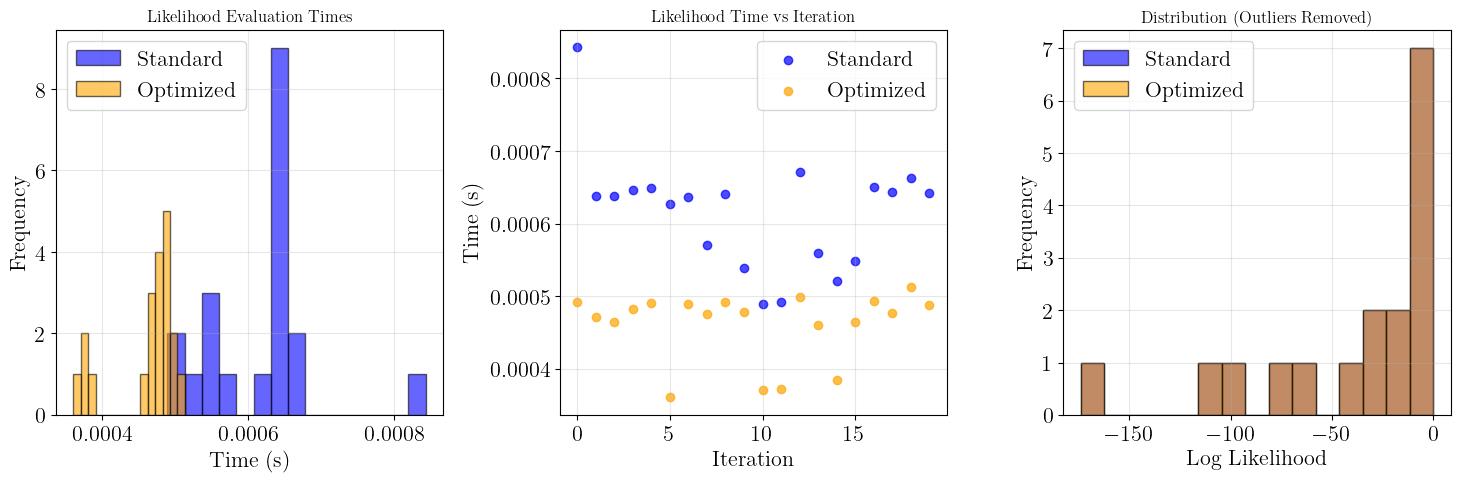

In [5]:
# ==============================================================================
# PER STAR ITERATION DIAGNOSTIC
# ==============================================================================
from IPython.display import display, clear_output
import jax
import jax.numpy as jnp
import numpy as np
import time
import datetime
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import tempfile
import os

from jesterTOV import utils
from jesterTOV.tov.data_classes import EOSData
from jesterTOV.inference.likelihoods.nicer import MockMRLikelihood, MockMRLikelihood_old

# ==============================================================================
# Generate mock CSV data for likelihood evaluation
# ==============================================================================
def generate_mock_csv(num_objects: int = 10, seed: int = 123) -> str:
    """
    Generate a CSV file with mock MR observations.
    """
    rng = np.random.default_rng(seed)

    mass_centers = rng.uniform(1.0, 2.0, size=num_objects)
    radius_centers = rng.uniform(10.0, 14.0, size=num_objects)

    mass_noise = mass_centers + rng.normal(0, 0.01, size=num_objects)
    radius_noise = radius_centers + rng.normal(0, 0.05, size=num_objects)

    std_mass = rng.uniform(0.02, 0.05, size=num_objects)
    std_radius = rng.uniform(0.02, 0.05, size=num_objects)

    correlations = rng.uniform(-0.5, 0.5, size=num_objects)
    covariances = correlations * std_mass * std_radius

    skew_mass = rng.uniform(-3.0, 3.0, size=num_objects)
    skew_radius = rng.uniform(-3.0, 3.0, size=num_objects)

    df = pd.DataFrame({
        "Mass_Center": [f"{m:.3f}" for m in mass_centers],
        "Radius_Center": [f"{r:.3f}" for r in radius_centers],
        "Mass_Center_Noise": [f"{m:.3f}" for m in mass_noise],
        "Radius_Center_Noise": [f"{r:.3f}" for r in radius_noise],
        "Std_Mass": [f"{s:.3f}" for s in std_mass],
        "Std_Radius": [f"{s:.3f}" for s in std_radius],
        "Covariance": [f"{c:.3f}" for c in covariances],
        "Skew_Mass": [f"{s:.3f}" for s in skew_mass],
        "Skew_Radius": [f"{s:.3f}" for s in skew_radius],
    })

    temp_file = tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False)
    df.to_csv(temp_file.name, index=False)
    temp_file.close()
    return temp_file.name

# ==============================================================================
# Check required variables exist (defined in previous cells)
# ==============================================================================
required_vars = ['input_dict', 'eos', 'st_solver']
for var in required_vars:
    if var not in globals():
        raise NameError(f"Variable '{var}' must be defined in a previous cell.")

# ==============================================================================
# Generate mock CSV (10 objects)
# ==============================================================================
csv_path = generate_mock_csv(num_objects=10)
print(f"Generated mock CSV with 10 objects at: {csv_path}")

# ==============================================================================
# Initialize likelihood objects
# ==============================================================================
print("Initializing MockMRLikelihood (standard)...")
likelihood_standard = MockMRLikelihood_old(
    csv_file=csv_path,
    penalty_value=-1e10,
    N_masses_evaluation=200
)

print("Initializing MockMRLikelihood_optimized...")
likelihood_optimized = MockMRLikelihood(
    csv_file=csv_path,
    penalty_value=-1e10,
    N_masses_evaluation=200
)

# Apply JAX JIT compilation to the evaluation methods
jitted_evaluate_standard = jax.jit(likelihood_standard.evaluate)
jitted_evaluate_optimized = jax.jit(likelihood_optimized.evaluate)

# ==============================================================================
# Main diagnostic loop (Sequential Evaluation)
# ==============================================================================
# Initialize PRNG key for JAX
key = jax.random.PRNGKey(42)

num_tests = 1000

# Storage for dynamic plotting
execution_times = []
beta_st_list = []
mr_curves = []
pe_curves = []
all_tov_iterations = []

# Storage for new CSV history export
csv_history_data = []

# Define fixed nsat grid for EOS sampling (0.001 to 15.0 nsat, log-spaced, 15 points matching batched version)
nsat_standard = 0.16
fixed_nsat_grid = np.logspace(np.log10(0.01), np.log10(15.0), 20)
fixed_ns_grid = fixed_nsat_grid * nsat_standard

# Generate timestamped filename for the CSV output
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
history_filename = f"phi0_iteration_history_seq_{timestamp}.csv"
first_csv_save = True

# Storage for likelihood timing and values
likelihood_times_standard = []
likelihood_times_optimized = []
likelihood_values_standard = []
likelihood_values_optimized = []

# Initialize 2x3 plot figure for main TOV properties
fig1, axes1 = plt.subplots(2, 3, figsize=(22, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.25)
axes1[1, 2].axis('off')  # Hide the bottom-right empty subplot

# Initialize 1x3 figure for likelihood timing and values
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3)

print("Starting real-time sequential diagnostic calculations with MR likelihood...")

for i in range(num_tests):
    # Split the key for all random variables
    key, *subkeys = jax.random.split(key, 17)

    # Sample parameters
    E_sat_val = float(jax.random.uniform(subkeys[0], minval=-16.1, maxval=-15.9))
    K_sat_val = float(jax.random.uniform(subkeys[1], minval=150.0, maxval=300.0))
    Q_sat_val = float(jax.random.uniform(subkeys[2], minval=-500.0, maxval=1100.0))
    Z_sat_val = float(jax.random.uniform(subkeys[3], minval=-2500.0, maxval=1500.0))
    E_sym_val = float(jax.random.uniform(subkeys[4], minval=28.0, maxval=45.0))
    L_sym_val = float(jax.random.uniform(subkeys[5], minval=10.0, maxval=200.0))
    K_sym_val = float(jax.random.uniform(subkeys[6], minval=-400.0, maxval=200.0))
    Q_sym_val = float(jax.random.uniform(subkeys[7], minval=-1000.0, maxval=1500.0))
    Z_sym_val = float(jax.random.uniform(subkeys[8], minval=-2000.0, maxval=1500.0))
    nbreak_val = float(jax.random.uniform(subkeys[9], minval=0.16, maxval=0.32))
    beta_ST_val = float(jax.random.uniform(subkeys[10], minval=-9.0, maxval=0.0))

    # Randomize CSE speed of sound squared (0.0 to 1.0 limit kausalitas!)
    random_cs2 = [
        float(jax.random.uniform(subkeys[11], minval=0.0, maxval=1.0)),
        float(jax.random.uniform(subkeys[12], minval=0.0, maxval=1.0)),
        float(jax.random.uniform(subkeys[13], minval=0.0, maxval=1.0)),
        float(jax.random.uniform(subkeys[14], minval=0.0, maxval=1.0)),
        float(jax.random.uniform(subkeys[15], minval=0.0, maxval=1.0))
    ]

    phi_c_val = 1.0
    phi_inf_tgt_val = 1e-3

    # Construct EOS dictionary
    current_input_dict = dict(input_dict)  # shallow copy
    current_input_dict.update({
        "E_sat": E_sat_val, "K_sat": K_sat_val, "Q_sat": Q_sat_val,
        "Z_sat": Z_sat_val, "E_sym": E_sym_val, "L_sym": L_sym_val,
        "K_sym": K_sym_val, "Q_sym": Q_sym_val, "Z_sym": Z_sym_val,
        "nbreak": nbreak_val,
        "cs2_CSE_0": random_cs2[0],
        "cs2_CSE_1": random_cs2[1],
        "cs2_CSE_2": random_cs2[2],
        "cs2_CSE_3": random_cs2[3],
        "cs2_CSE_4": random_cs2[4],
    })

    # Reconstruct EOS
    eos_out = eos.construct_eos(current_input_dict)
    current_eos_data = EOSData(
        ns=eos_out.ns, ps=eos_out.ps, hs=eos_out.hs,
        es=eos_out.es, dloge_dlogps=eos_out.dloge_dlogps, cs2=eos_out.cs2,
    )

    # ==========================================================================
    # ANTI-FLATLINE INTERPOLATION (Sequential Version)
    # ==========================================================================
    ns_arr = np.array(current_eos_data.ns)
    ps_arr = np.array(current_eos_data.ps)
    
    sort_idx = np.argsort(ns_arr)
    ns_arr_sorted = ns_arr[sort_idx]
    ps_arr_sorted = ps_arr[sort_idx]

    query_ns_grid = fixed_ns_grid
    if np.max(ns_arr_sorted) > 1e10:
        query_ns_grid = fixed_ns_grid * utils.fm_inv3_to_geometric 
        
    safe_ps_arr = np.where(ps_arr_sorted > 0, ps_arr_sorted, 1e-30)
    log_ps_arr_sorted = np.log10(safe_ps_arr)

    fixed_log_ps = np.interp(query_ns_grid, ns_arr_sorted, log_ps_arr_sorted)

    # Time the TOV execution
    tov_params = {
        "beta_ST": beta_ST_val,
        "phi_c": phi_c_val,
        "phi_inf_tgt": phi_inf_tgt_val
    }

    start_time = time.time()
    family = st_solver.construct_family(
        current_eos_data, ndat=200, min_nsat=0.1,
        tov_params=tov_params
    )
    family.masses.block_until_ready()
    calc_time = time.time() - start_time

    # Skip appending and plotting for the first compilation step.
    if i == 0:
        print("First iteration (compilation) compiling TOV and likelihoods, skipping timing measurements")
        compilation_params = {
            "masses_EOS": family.masses,
            "radii_EOS": family.radii
        }
        jitted_evaluate_standard(compilation_params).block_until_ready()
        jitted_evaluate_optimized(compilation_params).block_until_ready()
        continue

    # ==========================================================================
    # MR Likelihood Evaluation (Standard)
    # ==========================================================================
    params_likelihood = {
        "masses_EOS": family.masses,
        "radii_EOS": family.radii
    }

    start_lkl = time.time()
    lkl_standard = jitted_evaluate_standard(params_likelihood)
    lkl_standard.block_until_ready()
    lkl_time_standard = time.time() - start_lkl

    # ==========================================================================
    # MR Likelihood Evaluation (Optimized)
    # ==========================================================================
    start_lkl = time.time()
    lkl_optimized = jitted_evaluate_optimized(params_likelihood)
    lkl_optimized.block_until_ready()
    lkl_time_optimized = time.time() - start_lkl

    # Store likelihood results
    likelihood_times_standard.append(lkl_time_standard)
    likelihood_times_optimized.append(lkl_time_optimized)
    likelihood_values_standard.append(float(lkl_standard))
    likelihood_values_optimized.append(float(lkl_optimized))

    # Verify likelihood values match (within tolerance)
    diff = abs(float(lkl_standard) - float(lkl_optimized))
    if diff > 1e-6:
        print(f"WARNING: Likelihood mismatch at iteration {i}: "
              f"standard={float(lkl_standard):.6f}, "
              f"optimized={float(lkl_optimized):.6f}, "
              f"diff={diff:.6e}")

    # Extract, mask, and store physical data for plotting
    masses = np.array(family.masses)
    radii = np.array(family.radii)
    mask = (radii < 50) & (radii > 5) & (masses > 0.3)

    # Compile the history explicitly into the CSV payload list
    if hasattr(family, 'extra') and 'phi0_1st' in family.extra:
        valid_iters = np.array(family.extra['iterations'])[mask]
        all_tov_iterations.extend(valid_iters.tolist())
        
        valid_1st = np.array(family.extra['phi0_1st'])[mask]
        valid_2nd = np.array(family.extra['phi0_2nd'])[mask]
        valid_3rd = np.array(family.extra['phi0_3rd'])[mask]
        valid_prev = np.array(family.extra['phi0_prev'])[mask]
        valid_last = np.array(family.extra['phi0_last'])[mask]
        
        valid_m_first = np.array(family.extra['M_first'])[mask]
        valid_r_first = np.array(family.extra['R_first'])[mask]

        valid_pcs = np.array(family.extra['pc'])[mask]
        
        for k in range(len(valid_iters)):
            iters = int(valid_iters[k])
            pc_k = float(valid_pcs[k])
            
            row_dict = {
                "Iteration_Group": i,
                "TOV_Exec_Time_s": calc_time,
                "Lkl_Std_Time_s": lkl_time_standard,
                "Lkl_Opt_Time_s": lkl_time_optimized,
                "Beta_ST": beta_ST_val,
                "Star_Mass": float(valid_m_first[k]),      
                "Star_Radius": float(valid_r_first[k]),    
                "Total_Iters": iters,
                "Phi0_1st": float(valid_1st[k]),
                "Phi0_2nd": float(valid_2nd[k]),
                "Phi0_3rd": float(valid_3rd[k]),
                "Phi0_PrevLast": float(valid_prev[k]),
                "Phi0_Last": float(valid_last[k]),
                "cs2_CSE_0": random_cs2[0],
                "cs2_CSE_1": random_cs2[1],
                "cs2_CSE_2": random_cs2[2],
                "cs2_CSE_3": random_cs2[3],
                "cs2_CSE_4": random_cs2[4],
            }

            # Map the central values
            if pc_k > 0:
                row_dict["log_pc"] = float(np.log10(pc_k))
                row_dict["dloge_dlogps_c"] = float(np.interp(
                    pc_k, 
                    np.array(current_eos_data.ps), 
                    np.array(current_eos_data.dloge_dlogps)
                ))
            else:
                row_dict["log_pc"] = np.nan
                row_dict["dloge_dlogps_c"] = np.nan

            # Map the 15 points of log_ps
            for j in range(15):
                row_dict[f"nsat_{j+1}"] = float(fixed_nsat_grid[j])
                row_dict[f"log_ps_nsat_{j+1}"] = float(fixed_log_ps[j])

            csv_history_data.append(row_dict)

    # Store timing and parameter data
    execution_times.append(calc_time)
    beta_st_list.append(beta_ST_val)

    mr_curves.append((radii[mask], masses[mask]))

    es_plots = np.array(current_eos_data.es / utils.MeV_fm_inv3_to_geometric)
    ps_plots = np.array(current_eos_data.ps / utils.MeV_fm_inv3_to_geometric)

    mask_eos = es_plots >= 1
    es_plots = es_plots[mask_eos]
    ps_plots = ps_plots[mask_eos]

    pe_curves.append((es_plots, ps_plots))

    # ==========================================================================
    # Update real-time plots
    # ==========================================================================
    clear_output(wait=True)

    # Clear original figure axes
    for ax in axes1.flatten():
        ax.clear()
    axes1[1, 2].axis('off')

    # Clear likelihood figure axes
    for ax in axes2.flatten():
        ax.clear()

    # Define dynamic colormap
    if execution_times:
        norm = mcolors.Normalize(vmin=min(execution_times), vmax=max(execution_times))
        cmap = cm.viridis

        # 1. Histogram (top left)
        ax_hist = axes1[0, 0]
        ax_hist.hist(execution_times, bins=20, color='gray', edgecolor='black')
        ax_hist.set_title(f"Time Histogram (Iter {i+1}/{num_tests})\nLast: {calc_time:.4f} s")
        ax_hist.set_xlabel("Calculation Time (s)")
        ax_hist.set_ylabel("Frequency")

        # 2. Time vs Beta Scatter (top middle)
        scatter = axes1[0, 1].scatter(beta_st_list, execution_times,
                                      c=execution_times, cmap=cmap, norm=norm, edgecolor='k')
        axes1[0, 1].set_title(r"Execution Time vs $\beta_{ST}$")
        axes1[0, 1].set_xlabel(r"$\beta_{ST}$")
        axes1[0, 1].set_ylabel("Calculation Time (s)")
        axes1[0, 1].grid(True, alpha=0.3)

        # 3. Iteration Histogram (top right)
        ax_iter_hist = axes1[0, 2]
        if all_tov_iterations:
            min_iter = np.min(all_tov_iterations)
            max_iter = np.max(all_tov_iterations)
            
            if min_iter == max_iter:
                safe_bins = [min_iter - 0.5, min_iter + 0.5]
            else:
                safe_bins = min(20, int(max_iter - min_iter + 1))

            ax_iter_hist.hist(all_tov_iterations, bins=safe_bins, color='purple', edgecolor='black')
            
        ax_iter_hist.set_title("TOV Solver Iterations")
        ax_iter_hist.set_xlabel("Iterations per Star")
        ax_iter_hist.set_ylabel("Frequency")
        ax_iter_hist.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax_iter_hist.grid(True, alpha=0.3)

        # 4. Mass-Radius Curve (bottom left)
        ax_mr = axes1[1, 0]
        for idx, ((r, m), t) in enumerate(zip(mr_curves, execution_times)):
            ax_mr.plot(r, m, color=cmap(norm(t)), alpha=0.6, linewidth=1.5, zorder=idx)
        ax_mr.set_title("Mass-Radius Relations")
        ax_mr.set_xlabel("Radius (km)")
        ax_mr.set_ylabel(r"Mass ($M_\odot$)")
        ax_mr.set_xlim(8, 16)
        ax_mr.set_ylim(0.3, 3.0)
        ax_mr.grid(True, alpha=0.3)

        # 5. Pressure vs Energy Density (bottom middle)
        ax_pe = axes1[1, 1]
        for idx, ((e, p), t) in enumerate(zip(pe_curves, execution_times)):
            ax_pe.plot(e, p, color=cmap(norm(t)), alpha=0.6, linewidth=1.5, zorder=idx)
        ax_pe.set_title(r"Equation of State (P vs $\epsilon$)")
        ax_pe.set_xlabel(r"Energy Density (MeV fm$^{-3}$)")
        ax_pe.set_ylabel(r"Pressure (MeV fm$^{-3}$)")
        ax_pe.set_xscale('log')
        ax_pe.set_xlim(50, 1e3)
        ax_pe.set_yscale('log')
        ax_pe.grid(True, alpha=0.3)

        # Handle colorbar for original figure
        if not hasattr(fig1, 'colorbar_obj'):
            fig1.colorbar_obj = fig1.colorbar(scatter, ax=axes1.ravel().tolist(), label="Execution Time (s)")
        else:
            fig1.colorbar_obj.update_normal(scatter)

        # 6. Likelihood timing histogram (new figure left)
        ax_lkl_hist = axes2[0]
        ax_lkl_hist.hist(likelihood_times_standard, bins=15, alpha=0.6,
                         label='Standard', color='blue', edgecolor='black')
        ax_lkl_hist.hist(likelihood_times_optimized, bins=15, alpha=0.6,
                         label='Optimized', color='orange', edgecolor='black')
        ax_lkl_hist.set_title("Likelihood Evaluation Times")
        ax_lkl_hist.set_xlabel("Time (s)")
        ax_lkl_hist.set_ylabel("Frequency")
        ax_lkl_hist.legend()
        ax_lkl_hist.grid(True, alpha=0.3)

        # 7. Likelihood time comparison scatter (new figure middle)
        ax_lkl_scatter = axes2[1]
        iterations = list(range(len(likelihood_times_standard)))
        ax_lkl_scatter.scatter(iterations, likelihood_times_standard,
                               label='Standard', alpha=0.7, color='blue')
        ax_lkl_scatter.scatter(iterations, likelihood_times_optimized,
                               label='Optimized', alpha=0.7, color='orange')
        ax_lkl_scatter.set_title("Likelihood Time vs Iteration")
        ax_lkl_scatter.set_xlabel("Iteration")
        ax_lkl_scatter.set_ylabel("Time (s)")
        ax_lkl_scatter.legend()
        ax_lkl_scatter.grid(True, alpha=0.3)

        # 8. Likelihood values histogram (new figure right)
        ax_lkl_val = axes2[2]
        
        for data_raw, lbl, clr in zip([likelihood_values_standard, likelihood_values_optimized], 
                                      ['Standard', 'Optimized'], ['blue', 'orange']):
            
            data = np.asarray(data_raw)
            if len(data) > 0:
                # IQR filtering
                q1, q3 = np.percentile(data, [25, 75])
                iqr = q3 - q1
                mask_iqr = (data >= q1 - 1.5 * iqr) & (data <= q3 + 1.5 * iqr)
                filtered = data[mask_iqr]
                
                ax_lkl_val.hist(filtered, bins=15, alpha=0.6, label=lbl, color=clr, edgecolor='black')
        
        ax_lkl_val.set_title("Distribution (Outliers Removed)")
        ax_lkl_val.set_xlabel("Log Likelihood")
        ax_lkl_val.set_ylabel("Frequency")
        ax_lkl_val.legend()
        ax_lkl_val.grid(True, alpha=0.3)

        # Display both figures
        display(fig1)
        display(fig2)

    # Save tracking history to CSV periodically
    if (i + 1) % 10 == 0 and csv_history_data:
        df_export = pd.DataFrame(csv_history_data)
        df_export.to_csv(history_filename, mode='a', index=False, header=first_csv_save)
        first_csv_save = False
        csv_history_data.clear()

# Clean up temporary CSV file
os.unlink(csv_path)
print(f"Removed temporary CSV file: {csv_path}")

plt.close('all')

# Write remaining history records
if csv_history_data:
    df_export = pd.DataFrame(csv_history_data)
    df_export.to_csv(history_filename, mode='a', index=False, header=first_csv_save)

print(f"\nSaved tracking history to '{history_filename}'")

# ==============================================================================
# Final summary statistics
# ==============================================================================
print("\n" + "="*60)
print("DIAGNOSTIC COMPLETE SUMMARY STATISTICS")
print("="*60)

print(f"Total iterations (excluding compilation): {len(execution_times)}\n")

# Format execution times into a Pandas DataFrame Table
summary_data = {
    "Metric": ["Mean", "Std", "Min", "Max"],
    "TOV Solver (s)": [
        np.mean(execution_times), 
        np.std(execution_times), 
        np.min(execution_times), 
        np.max(execution_times)
    ],
    "Likelihood Std (s)": [
        np.mean(likelihood_times_standard), 
        np.std(likelihood_times_standard), 
        np.min(likelihood_times_standard), 
        np.max(likelihood_times_standard)
    ],
    "Likelihood Opt (s)": [
        np.mean(likelihood_times_optimized), 
        np.std(likelihood_times_optimized), 
        np.min(likelihood_times_optimized), 
        np.max(likelihood_times_optimized)
    ]
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

speedup_mean = np.mean(likelihood_times_standard) / np.mean(likelihood_times_optimized)
speedup_median = np.median(likelihood_times_standard) / np.median(likelihood_times_optimized)
print(f"\nOptimization Speedup:")
print(f"  Mean speedup:   {speedup_mean:.2f}x")
print(f"  Median speedup: {speedup_median:.2f}x")

# Verify likelihood values are consistent
lkl_diff = np.abs(np.array(likelihood_values_standard) - np.array(likelihood_values_optimized))
max_diff = np.max(lkl_diff)
print(f"\nLikelihood Consistency Check:")
print(f"  Maximum absolute difference: {max_diff:.6e}")
if max_diff < 1e-6:
    print("  ✓ Likelihood values match within tolerance (1e-6)")
else:
    print(f"  ⚠ Likelihood values differ (max diff = {max_diff:.2e})")

print("\nDiagnostic finished successfully.")

In [ ]:
# -----------------------------------------------------------------------------
# Spectral EOS + ST & GR TOV solver: Diagnostic Loop with MR Likelihood
# -----------------------------------------------------------------------------
# Expected pre-defined variables:
#   - eos:        SpectralDecomposition_EOS_model instance
#   - st_solver:  ScalarTensorTOVSolver instance
#   - gr_solver:  GRTOVSolver instance
# -----------------------------------------------------------------------------
from IPython.display import display, clear_output
import jax
import jax.numpy as jnp
import numpy as np
import time
import datetime
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import pandas as pd
import tempfile
import os

from jesterTOV import utils
from jesterTOV.tov.data_classes import EOSData
from jesterTOV.inference.likelihoods.nicer import MockMRLikelihood, MockMRLikelihood_old
from jesterTOV.eos.spectral import SpectralDecomposition_EOS_model

# ==============================================================================
# Helper Functions
# ==============================================================================
@jax.jit
@jax.vmap
def _compute_derived_vmap(m_c, r_c, m_n_raw, r_n_raw, std_m, std_r, corr):
    m_noise = m_c + m_n_raw
    r_noise = r_c + r_n_raw
    cov = corr * std_m * std_r
    return m_noise, r_noise, cov

def generate_mock_csv(num_objects: int = 10, seed: int = 123) -> str:
    rng = np.random.default_rng(seed)
    mass_centers = rng.uniform(1.0, 2.0, size=num_objects)
    radius_centers = rng.uniform(10.0, 14.0, size=num_objects)
    raw_mass_noise = rng.normal(0, 0.01, size=num_objects)
    raw_radius_noise = rng.normal(0, 0.05, size=num_objects)
    std_mass = rng.uniform(0.02, 0.05, size=num_objects)
    std_radius = rng.uniform(0.02, 0.05, size=num_objects)
    correlations = rng.uniform(-0.5, 0.5, size=num_objects)
    skew_mass = rng.uniform(-3.0, 3.0, size=num_objects)
    skew_radius = rng.uniform(-3.0, 3.0, size=num_objects)

    mass_noise, radius_noise, covariances = _compute_derived_vmap(
        jnp.array(mass_centers), jnp.array(radius_centers),
        jnp.array(raw_mass_noise), jnp.array(raw_radius_noise),
        jnp.array(std_mass), jnp.array(std_radius), jnp.array(correlations)
    )

    mass_noise = np.array(mass_noise)
    radius_noise = np.array(radius_noise)
    covariances = np.array(covariances)

    df = pd.DataFrame({
        "Mass_Center": [f"{m:.3f}" for m in mass_centers],
        "Radius_Center": [f"{r:.3f}" for r in radius_centers],
        "Mass_Center_Noise": [f"{m:.3f}" for m in mass_noise],
        "Radius_Center_Noise": [f"{r:.3f}" for r in radius_noise],
        "Std_Mass": [f"{s:.3f}" for s in std_mass],
        "Std_Radius": [f"{s:.3f}" for s in std_radius],
        "Covariance": [f"{c:.3f}" for c in covariances],
        "Skew_Mass": [f"{s:.3f}" for s in skew_mass],
        "Skew_Radius": [f"{s:.3f}" for s in skew_radius],
    })
    temp_file = tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False)
    df.to_csv(temp_file.name, index=False)
    temp_file.close()
    return temp_file.name

# ==============================================================================
# Initialization
# ==============================================================================
eos = SpectralDecomposition_EOS_model(crust_name = "DH") #crust_name = "SLy"

csv_path = generate_mock_csv(num_objects=10)
print(f"Generated mock CSV with 10 objects at: {csv_path}")

likelihood_standard = MockMRLikelihood_old(csv_file=csv_path, penalty_value=-1e10, N_masses_evaluation=200)
likelihood_optimized = MockMRLikelihood(csv_file=csv_path, penalty_value=-1e10, N_masses_evaluation=200)

# Vectorized EOS validation using vmap
def check_eos_validity(g0, g1, g2, g3):
    params = {"gamma_0": g0, "gamma_1": g1, "gamma_2": g2, "gamma_3": g3}
    eos_out = eos.construct_eos(params)
    return eos_out.extra_constraints["n_gamma_violations"]

vmap_check_eos = jax.jit(jax.vmap(check_eos_validity))

# ==============================================================================
# Define Core JAX VMAP Pipeline for Solvers
# ==============================================================================
nsat_standard = 0.16
# 15 log-spaced points from 0.001 to 15.0 nsat
fixed_nsat_grid = jnp.logspace(jnp.log10(0.01), jnp.log10(15.0), 20)
fixed_ns_grid = fixed_nsat_grid * nsat_standard

def compute_single_spectral_model(rand_params):
    params_spectral = {
        "gamma_0": rand_params["gamma_0"],
        "gamma_1": rand_params["gamma_1"],
        "gamma_2": rand_params["gamma_2"],
        "gamma_3": rand_params["gamma_3"],
    }
    beta_ST_val = rand_params["beta_ST"]

    eos_out = eos.construct_eos(params_spectral)
    current_eos_data = EOSData(
        ns=eos_out.ns, ps=eos_out.ps, hs=eos_out.hs,
        es=eos_out.es, dloge_dlogps=eos_out.dloge_dlogps, cs2=eos_out.cs2,
        extra_constraints=eos_out.extra_constraints,
    )

    # ANTI-FLATLINE INTERPOLATION (JAX NATIVE)
    ns_arr = eos_out.ns
    ps_arr = eos_out.ps
    sort_idx = jnp.argsort(ns_arr)
    ns_arr_sorted = ns_arr[sort_idx]
    ps_arr_sorted = ps_arr[sort_idx]

    max_ns = jnp.max(ns_arr_sorted)
    query_ns_grid = jnp.where(max_ns > 1e10, fixed_ns_grid * utils.fm_inv3_to_geometric, fixed_ns_grid)
    
    # Extract log pressure directly
    safe_ps_arr = jnp.where(ps_arr_sorted > 0, ps_arr_sorted, 1e-30)
    log_ps_arr_sorted = jnp.log10(safe_ps_arr)

    fixed_log_ps = jnp.interp(query_ns_grid, ns_arr_sorted, log_ps_arr_sorted)

    # ---------------- ST Solver ----------------
    tov_params_st = {"beta_ST": beta_ST_val, "phi_c": 1.0, "phi_inf_tgt": 1e-3}
    family_st = st_solver.construct_family(
        current_eos_data, ndat=200, min_nsat=0.1, tov_params=tov_params_st
    )

    # ---------------- GR Solver ----------------
    tov_params_gr = {}
    family_gr = gr_solver.construct_family(
        current_eos_data, ndat=200, min_nsat=0.1, tov_params=tov_params_gr
    )

    # Likelihood Evaluation (Evaluated on ST Family)
    params_likelihood = {"masses_EOS": family_st.masses, "radii_EOS": family_st.radii}
    lkl_std = likelihood_standard.evaluate(params_likelihood)
    lkl_opt = likelihood_optimized.evaluate(params_likelihood)

    # Extract central values mapping
    log10pcs_st = family_st.log10pcs
    pc_geom = 10.0 ** log10pcs_st
    hc_k = jnp.interp(pc_geom, eos_out.ps, eos_out.hs)
    dloge_c = jnp.interp(hc_k, eos_out.hs, eos_out.dloge_dlogps)

    return {
        "masses_st": family_st.masses,
        "radii_st": family_st.radii,
        "log10pcs_st": log10pcs_st,
        "extra_st": family_st.extra,
        "masses_gr": family_gr.masses,
        "radii_gr": family_gr.radii,
        "lkl_std": lkl_std,
        "lkl_opt": lkl_opt,
        "fixed_log_ps": fixed_log_ps,
        "es_raw": eos_out.es,
        "ps_raw": eos_out.ps,
        "dloge_c": dloge_c
    }

batched_spectral_pipeline = jax.jit(jax.vmap(compute_single_spectral_model))

# ==============================================================================
# Main Diagnostic Loop
# ==============================================================================
key = jax.random.PRNGKey(int(time.time()))
num_tests = 1000
batch_size_draws = 50000
batch_size_compute = 10

execution_times, beta_st_list = [], []
gamma_0_list, gamma_1_list, gamma_2_list, gamma_3_list = [], [], [], []
mr_curves_st, mr_curves_gr, pe_curves = [], [], []
csv_history_data = []

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
history_filename = f"spectral_st_diagnostics_{timestamp}.csv"
first_csv_save = True

likelihood_times_standard, likelihood_times_optimized = [], []
likelihood_values_standard, likelihood_values_optimized = [], []
gamma_violations_all = []

fig1, axes1 = plt.subplots(2, 3, figsize=(22, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3)

print("Starting vectorized real-time diagnostic calculations...")

valid_count = 0
total_draws = 0
n_skipped = 0
compilation_done = False
valid_params_queue = []

while valid_count < num_tests:
    # 1. Bulk generate and filter parameters via vmap
    if len(valid_params_queue) == 0:
        print(f"\nSampling {batch_size_draws} parameter sets via JAX vmap...")
        key, *subkeys = jax.random.split(key, 6)
        
        g0_arr = jax.random.uniform(subkeys[0], minval=0.2, maxval=2.0, shape=(batch_size_draws,))
        g1_arr = jax.random.uniform(subkeys[1], minval=-1.6, maxval=1.7, shape=(batch_size_draws,))
        g2_arr = jax.random.uniform(subkeys[2], minval=-0.6, maxval=0.6, shape=(batch_size_draws,))
        g3_arr = jax.random.uniform(subkeys[3], minval=-0.02, maxval=0.02, shape=(batch_size_draws,))
        beta_arr = jax.random.uniform(subkeys[4], minval=-9.0, maxval=0.0, shape=(batch_size_draws,))
        
        start_vmap = time.time()
        viols = vmap_check_eos(g0_arr, g1_arr, g2_arr, g3_arr)
        viols_flat = np.array(viols).flatten()
        vmap_time = time.time() - start_vmap
        
        gamma_violations_all.extend(viols_flat.tolist())
        valid_idx = np.where(viols_flat == 0)[0]
        n_skipped += (batch_size_draws - len(valid_idx))
        total_draws += batch_size_draws
        
        print(f"Vmap completed in {vmap_time:.3f} s. Found {len(valid_idx)} valid EOS.")
        
        for idx in valid_idx:
            valid_params_queue.append({
                "gamma_0": float(g0_arr[idx]),
                "gamma_1": float(g1_arr[idx]),
                "gamma_2": float(g2_arr[idx]),
                "gamma_3": float(g3_arr[idx]),
                "beta_ST": float(beta_arr[idx])
            })
            
        if len(valid_params_queue) == 0:
            continue

    # 2. Extract up to 10 valid EOS for the batched solver loop
    batch_to_process = []
    while valid_params_queue and len(batch_to_process) < batch_size_compute and valid_count + len(batch_to_process) < num_tests:
        batch_to_process.append(valid_params_queue.pop(0))

    current_batch_size = len(batch_to_process)
    if current_batch_size == 0:
        continue

    # Reformat for JAX vmap ingestion
    batched_params = {
        "gamma_0": jnp.array([p["gamma_0"] for p in batch_to_process]),
        "gamma_1": jnp.array([p["gamma_1"] for p in batch_to_process]),
        "gamma_2": jnp.array([p["gamma_2"] for p in batch_to_process]),
        "gamma_3": jnp.array([p["gamma_3"] for p in batch_to_process]),
        "beta_ST": jnp.array([p["beta_ST"] for p in batch_to_process]),
    }

    # 3. Solve TOV (ST & GR) and evaluate likelihoods via VMAP
    start_time = time.time()
    batch_results = batched_spectral_pipeline(batched_params)
    batch_results["masses_st"].block_until_ready()
    calc_time = time.time() - start_time

    if not compilation_done:
        print("First iteration (compilation) complete. Skipping timing measurements for this batch.")
        compilation_done = True
        continue

    # Convert JAX arrays to numpy arrays (using the fixed tree.map!)
    br = jax.tree.map(np.array, batch_results)
    calc_time_per_model = calc_time / current_batch_size

    # Unpack the batch and save metrics
    for j in range(current_batch_size):
        # Extract ST data
        masses_st = br["masses_st"][j]
        radii_st = br["radii_st"][j]
        mask_st = ~np.isnan(radii_st) & ~np.isnan(masses_st) & (masses_st > 0.0) & (radii_st > 0.0)
        
        # Extract GR data
        masses_gr = br["masses_gr"][j]
        radii_gr = br["radii_gr"][j]
        mask_gr = ~np.isnan(radii_gr) & ~np.isnan(masses_gr) & (masses_gr > 0.0) & (radii_gr > 0.0)

        # Likelihood values
        lkl_std_val = float(br["lkl_std"][j])
        lkl_opt_val = float(br["lkl_opt"][j])
        
        likelihood_times_standard.append(calc_time_per_model)
        likelihood_times_optimized.append(calc_time_per_model)
        likelihood_values_standard.append(lkl_std_val)
        likelihood_values_optimized.append(lkl_opt_val)

        # ST internal tracking info (NN Targets)
        extra = {k: v[j] for k, v in br["extra_st"].items()} if br["extra_st"] else {}
        if extra and 'phi0_1st' in extra:
            valid_iters = extra['iterations'][mask_st]
            valid_1st = extra['phi0_1st'][mask_st]
            valid_2nd = extra['phi0_2nd'][mask_st]
            valid_3rd = extra['phi0_3rd'][mask_st]
            valid_prev = extra['phi0_prev'][mask_st]
            valid_last = extra['phi0_last'][mask_st]
            valid_m_first = extra['M_first'][mask_st]
            valid_r_first = extra['R_first'][mask_st]
            
            pcs = br["log10pcs_st"][j][mask_st]
            dloge_c_arr = br["dloge_c"][j][mask_st]
            fixed_log_ps_j = br["fixed_log_ps"][j]

            for k in range(min(len(masses_st[mask_st]), 50)): 
                row_dict = {
                    "Iteration_Group":      valid_count,
                    "TOV_Exec_Time_s":      calc_time_per_model,
                    "Lkl_Std_Time_s":       calc_time_per_model,
                    "Lkl_Opt_Time_s":       calc_time_per_model,
                    "Gamma_0":              float(batched_params["gamma_0"][j]),
                    "Gamma_1":              float(batched_params["gamma_1"][j]),
                    "Gamma_2":              float(batched_params["gamma_2"][j]),
                    "Gamma_3":              float(batched_params["gamma_3"][j]),
                    "Beta_ST":              float(batched_params["beta_ST"][j]),
                    "N_Gamma_Violations":   0,
                    # --- Target fields for NN ---
                    "Star_Mass":            float(valid_m_first[k]),      
                    "Star_Radius":          float(valid_r_first[k]),    
                    "Total_Iters":          int(valid_iters[k]),
                    "Phi0_1st":             float(valid_1st[k]),
                    "Phi0_2nd":             float(valid_2nd[k]),
                    "Phi0_3rd":             float(valid_3rd[k]),
                    "Phi0_PrevLast":        float(valid_prev[k]),
                    "Phi0_Last":            float(valid_last[k]),
                }
                
                # Dynamic mapping for 15 fixed nsat log pressure evaluation points
                for p_idx in range(20):
                    row_dict[f"nsat_{p_idx+1}"] = float(np.array(fixed_nsat_grid)[p_idx])
                    row_dict[f"log_ps_nsat_{p_idx+1}"] = float(fixed_log_ps_j[p_idx])

                if k < len(pcs):
                    row_dict["log_pc"] = float(pcs[k])
                    row_dict["dloge_dlogps_c"] = float(dloge_c_arr[k])

                csv_history_data.append(row_dict)

        valid_count += 1
        execution_times.append(calc_time_per_model)
        beta_st_list.append(float(batched_params["beta_ST"][j]))
        gamma_0_list.append(float(batched_params["gamma_0"][j]))
        gamma_1_list.append(float(batched_params["gamma_1"][j]))
        gamma_2_list.append(float(batched_params["gamma_2"][j]))
        gamma_3_list.append(float(batched_params["gamma_3"][j]))
        
        mr_curves_st.append((radii_st[mask_st], masses_st[mask_st]))
        mr_curves_gr.append((radii_gr[mask_gr], masses_gr[mask_gr]))

        es_plots = br["es_raw"][j] / utils.MeV_fm_inv3_to_geometric
        ps_plots = br["ps_raw"][j] / utils.MeV_fm_inv3_to_geometric
        mask_eos = es_plots >= 1
        pe_curves.append((es_plots[mask_eos], ps_plots[mask_eos]))

    # 4. Update real-time plots after processing the batch
    clear_output(wait=True)
    print(f"Status: {valid_count}/{num_tests} valid EOS simulated. Total evaluated: {total_draws}. Skipped: {n_skipped}.")

    for ax in axes1.flatten(): ax.clear()
    for ax in axes2.flatten(): ax.clear()

    if execution_times:
        norm = mcolors.Normalize(vmin=min(execution_times), vmax=max(execution_times))
        cmap = cm.viridis

        ax_hist = axes1[0, 0]
        ax_hist.hist(execution_times, bins=20, color='gray', edgecolor='black')
        ax_hist.set_title(f"Time Histogram (Valid {valid_count}/{num_tests})\nLast Avg: {execution_times[-1]:.4f} s")
        ax_hist.set_xlabel("Calculation Time (s)")
        ax_hist.set_ylabel("Frequency")

        ax_gamma = axes1[0, 1]
        n_viol = np.array(gamma_violations_all)
        ax_gamma.hist(n_viol, bins=range(0, max(5, int(n_viol.max()) + 2)), color='crimson', edgecolor='black', alpha=0.7)
        ax_gamma.set_title(r"Gamma Bound Violations (all draws)")
        ax_gamma.set_xlabel("N Violations")
        ax_gamma.set_ylabel("Frequency")
        ax_gamma.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax_gamma.grid(True, alpha=0.3)

        scatter = axes1[0, 2].scatter(beta_st_list, execution_times, c=execution_times, cmap=cmap, norm=norm, edgecolor='k', alpha=0.6)
        axes1[0, 2].set_title(r"Execution Time vs $\beta_{ST}$")
        axes1[0, 2].set_xlabel(r"$\beta_{ST}$")
        axes1[0, 2].set_ylabel("Calculation Time (s)")
        axes1[0, 2].grid(True, alpha=0.3)

        ax_mr_st = axes1[1, 0]
        for idx, ((r, m), t) in enumerate(zip(mr_curves_st, execution_times)):
            ax_mr_st.plot(r, m, color=cmap(norm(t)), alpha=0.6, linewidth=1.5, zorder=idx)
        ax_mr_st.set_title("Mass-Radius Relations (ST)")
        ax_mr_st.set_xlabel("Radius (km)")
        ax_mr_st.set_ylabel(r"Mass ($M_\odot$)")
        ax_mr_st.set_xlim(8, 16)
        ax_mr_st.set_ylim(0.3, 3.0)
        ax_mr_st.grid(True, alpha=0.3)

        ax_pe = axes1[1, 1]
        for idx, ((e, p), t) in enumerate(zip(pe_curves, execution_times)):
            ax_pe.plot(e, p, color=cmap(norm(t)), alpha=0.6, linewidth=1.5, zorder=idx)
        ax_pe.set_title(r"Spectral EOS ($P$ vs $\epsilon$)")
        ax_pe.set_xlabel(r"Energy Density (MeV fm$^{-3}$)")
        ax_pe.set_ylabel(r"Pressure (MeV fm$^{-3}$)")
        ax_pe.set_xscale('log')
        ax_pe.set_xlim(50, 1e3)
        ax_pe.set_yscale('log')
        ax_pe.grid(True, alpha=0.3)

        # ---------------- GR Plot Box ----------------
        ax_mr_gr = axes1[1, 2]
        for idx, ((r, m), t) in enumerate(zip(mr_curves_gr, execution_times)):
            ax_mr_gr.plot(r, m, color=cmap(norm(t)), alpha=0.6, linewidth=1.5, zorder=idx)
        ax_mr_gr.set_title("Mass-Radius Relations (GR)")
        ax_mr_gr.set_xlabel("Radius (km)")
        ax_mr_gr.set_ylabel(r"Mass ($M_\odot$)")
        ax_mr_gr.set_xlim(8, 16)
        ax_mr_gr.set_ylim(0.3, 3.0)
        ax_mr_gr.grid(True, alpha=0.3)

        if not hasattr(fig1, 'colorbar_obj'):
            fig1.colorbar_obj = fig1.colorbar(scatter, ax=axes1.ravel().tolist(), label="Execution Time (s)")
        else:
            fig1.colorbar_obj.update_normal(scatter)

        ax_lkl_hist = axes2[0]
        ax_lkl_hist.hist(likelihood_times_standard, bins=15, alpha=0.6, label='Standard', color='blue', edgecolor='black')
        ax_lkl_hist.hist(likelihood_times_optimized, bins=15, alpha=0.6, label='Optimized', color='orange', edgecolor='black')
        ax_lkl_hist.set_title("Likelihood Evaluation Times")
        ax_lkl_hist.set_xlabel("Time (s)")
        ax_lkl_hist.set_ylabel("Frequency")
        ax_lkl_hist.legend()
        ax_lkl_hist.grid(True, alpha=0.3)

        ax_lkl_scatter = axes2[1]
        iterations = list(range(len(likelihood_times_standard)))
        ax_lkl_scatter.scatter(iterations, likelihood_times_standard, label='Standard', alpha=0.7, color='blue', s=8)
        ax_lkl_scatter.scatter(iterations, likelihood_times_optimized, label='Optimized', alpha=0.7, color='orange', s=8)
        ax_lkl_scatter.set_title("Likelihood Time vs Iteration")
        ax_lkl_scatter.set_xlabel("Iteration")
        ax_lkl_scatter.set_ylabel("Time (s)")
        ax_lkl_scatter.legend()
        ax_lkl_scatter.grid(True, alpha=0.3)

        ax_lkl_val = axes2[2]
        for data_raw, lbl, clr in zip([likelihood_values_standard, likelihood_values_optimized], ['Standard', 'Optimized'], ['blue', 'orange']):
            data = np.asarray(data_raw)
            q1, q3 = np.percentile(data, [25, 75])
            iqr = q3 - q1
            mask_val = (data >= q1 - 1.5 * iqr) & (data <= q3 + 1.5 * iqr)
            filtered = data[mask_val]
            ax_lkl_val.hist(filtered, bins=15, alpha=0.6, label=lbl, color=clr, edgecolor='black')
        ax_lkl_val.set_title("Distribution (Outliers Removed)")
        ax_lkl_val.set_xlabel("Log Likelihood")
        ax_lkl_val.set_ylabel("Frequency")
        ax_lkl_val.legend()
        ax_lkl_val.grid(True, alpha=0.3)

        display(fig1)
        display(fig2)

    # WRITE CSV EVERY BATCH OF PARAMETERS
    if csv_history_data:
        df_export = pd.DataFrame(csv_history_data)
        df_export.to_csv(history_filename, mode='a', index=False, header=first_csv_save)
        first_csv_save = False
        csv_history_data.clear()

os.unlink(csv_path)
print(f"Removed temporary CSV file: {csv_path}")
plt.close('all')

if csv_history_data:
    df_export = pd.DataFrame(csv_history_data)
    df_export.to_csv(history_filename, mode='a', index=False, header=first_csv_save)

print(f"\nSaved tracking history to '{history_filename}'")

In [ ]:
fufufafa

In [ ]:
# 
# ------------------------------------------------------------------------------
# Imports (Stripped down for pure data generation)
# 
# ------------------------------------------------------------------------------
import jax
import jax.numpy as jnp
import numpy as np
import time
import pandas as pd

from jesterTOV import utils
from jesterTOV.tov.data_classes import EOSData

# 
# ------------------------------------------------------------------------------
# Check required variables exist (defined in previous cells)
# 
# ------------------------------------------------------------------------------
required_vars = ['input_dict', 'eos', 'ScalarTensorTOVSolver']
for var in required_vars:
    if var not in globals():
        raise NameError(f"Variable '{var}' must be defined in a previous cell.")

# Re-initialize solver to ensure clean state with the updated backend
st_solver = ScalarTensorTOVSolver(calculate_tidal=True)

# 
# ------------------------------------------------------------------------------
# Main high-speed data collection loop
# 
# ------------------------------------------------------------------------------
# Initialize PRNG key for JAX
key = jax.random.PRNGKey(42)

# Adjust this number to whatever you need for your actual run
num_tests = 100 

csv_history_data = []

print(f"Starting high-speed scalar-tensor calculations for {num_tests} parameter sets...")
start_global_time = time.time()

for i in range(num_tests):
    key, *subkeys = jax.random.split(key, 12)

    # Sample parameters
    E_sat_val = jax.random.uniform(subkeys[0], minval=-16.1, maxval=-15.9)
    K_sat_val = jax.random.uniform(subkeys[1], minval=150.0, maxval=300.0)
    Q_sat_val = jax.random.uniform(subkeys[2], minval=-500.0, maxval=1100.0)
    Z_sat_val = jax.random.uniform(subkeys[3], minval=-2500.0, maxval=1500.0)
    E_sym_val = jax.random.uniform(subkeys[4], minval=28.0, maxval=45.0)
    L_sym_val = jax.random.uniform(subkeys[5], minval=10.0, maxval=200.0)
    K_sym_val = jax.random.uniform(subkeys[6], minval=-400.0, maxval=200.0)
    Q_sym_val = jax.random.uniform(subkeys[7], minval=-1000.0, maxval=1500.0)
    Z_sym_val = jax.random.uniform(subkeys[8], minval=-2000.0, maxval=1500.0)
    nbreak_val = jax.random.uniform(subkeys[9], minval=0.16, maxval=0.32)
    beta_ST_val = float(jax.random.uniform(subkeys[10], minval=-9.0, maxval=0.0))

    phi_c_val = 1.0
    phi_inf_tgt_val = 1e-3

    # Construct EOS dictionary
    current_input_dict = input_dict.copy()
    current_input_dict.update({
        "E_sat": E_sat_val, "K_sat": K_sat_val, "Q_sat": Q_sat_val,
        "Z_sat": Z_sat_val, "E_sym": E_sym_val, "L_sym": L_sym_val,
        "K_sym": K_sym_val, "Q_sym": Q_sym_val, "Z_sym": Z_sym_val,
        "nbreak": nbreak_val,
    })

    # Reconstruct EOS
    eos_out = eos.construct_eos(current_input_dict)
    current_eos_data = EOSData(
        ns=eos_out.ns, ps=eos_out.ps, hs=eos_out.hs,
        es=eos_out.es, dloge_dlogps=eos_out.dloge_dlogps, cs2=eos_out.cs2,
    )

    # TOV Execution
    tov_params = {
        "beta_ST": beta_ST_val,
        "phi_c": phi_c_val,
        "phi_inf_tgt": phi_inf_tgt_val
    }

    family = st_solver.construct_family(
        current_eos_data, ndat=200, min_nsat=0.1,
        tov_params=tov_params
    )
    
    # Block until JAX finishes compiling/executing this batch on the GPU
    family.masses.block_until_ready()

    # Skip appending for the very first compilation step to avoid polluting data 
    # if JAX produces NaNs during initial trace tracing.
    if i == 0:
        print("First iteration (JAX compilation) finished.")
        continue

    # Extract, mask, and store physical data
    masses = np.array(family.masses)
    radii = np.array(family.radii)
    mask = (radii < 50) & (radii > 5) & (masses > 0.3)

    # Compile the history tensor explicitly into the CSV payload list
    if hasattr(family, 'extra') and 'phi0_1st' in family.extra:
        valid_iters = np.array(family.extra['iterations'])[mask]
        
        valid_1st = np.array(family.extra['phi0_1st'])[mask]
        valid_2nd = np.array(family.extra['phi0_2nd'])[mask]
        valid_3rd = np.array(family.extra['phi0_3rd'])[mask]
        valid_prev = np.array(family.extra['phi0_prev'])[mask]
        valid_last = np.array(family.extra['phi0_last'])[mask]
        
        # Extracted the specific First Iteration M and R mapped outputs
        valid_m_first = np.array(family.extra['M_first'])[mask]
        valid_r_first = np.array(family.extra['R_first'])[mask]
        
        for k in range(len(valid_iters)):
            iters = int(valid_iters[k])
            
            csv_history_data.append({
                "Iteration_Group": i,
                "Beta_ST": beta_ST_val,
                "Star_Mass": float(valid_m_first[k]),      # Mass from the 1st iteration
                "Star_Radius": float(valid_r_first[k]),    # Radius from the 1st iteration
                "Total_Iters": iters,
                "Phi0_1st": float(valid_1st[k]),
                "Phi0_2nd": float(valid_2nd[k]),
                "Phi0_3rd": float(valid_3rd[k]),
                "Phi0_PrevLast": float(valid_prev[k]),
                "Phi0_Last": float(valid_last[k])
            })

    # Progress Indicator
    if (i + 1) % 10 == 0:
        elapsed = time.time() - start_global_time
        print(f"Processed {i + 1}/{num_tests} parameter sets. Elapsed time: {elapsed:.2f} s")

# 
# ------------------------------------------------------------------------------
# Export Results
# 
# ------------------------------------------------------------------------------
total_time = time.time() - start_global_time
print("\n" + "="*60)
print(f"CALCULATIONS COMPLETE in {total_time:.2f} seconds.")
print("="*60)

# Write history records natively directly to csv via pandas 
if csv_history_data:
    df_export = pd.DataFrame(csv_history_data)
    export_filename = "phi0_iteration_history.csv"
    df_export.to_csv(export_filename, index=False)
    print(f"Successfully saved {len(df_export)} physical star tracking records to '{export_filename}'.")
else:
    print("Warning: No valid records were found to export. Check your masking parameters or backend outputs.")

In [ ]:
fffff 
grids, Dopri8:
1024: 9
256: 3.6
64: 2.8
32: 2.3
16: 2.2

Dopri5:
128: 3.8
16: 2.29

In [ ]:
# 
# ------------------------------------------------------------------------------
# Imports (including original imports)
# 
# ------------------------------------------------------------------------------
from IPython.display import display, clear_output
import jax
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import tempfile
import os

from jesterTOV import utils
from jesterTOV.tov.data_classes import EOSData
from jesterTOV.inference.likelihoods.nicer import MockMRLikelihood, MockMRLikelihood_old

# 
# ------------------------------------------------------------------------------
# Generate mock CSV data for likelihood evaluation
# 
# ------------------------------------------------------------------------------
def generate_mock_csv(num_objects: int = 10, seed: int = 123) -> str:
    """
    Generate a CSV file with mock MR observations.
    """
    rng = np.random.default_rng(seed)

    mass_centers = rng.uniform(1.0, 2.0, size=num_objects)
    radius_centers = rng.uniform(10.0, 14.0, size=num_objects)

    mass_noise = mass_centers + rng.normal(0, 0.01, size=num_objects)
    radius_noise = radius_centers + rng.normal(0, 0.05, size=num_objects)

    std_mass = rng.uniform(0.02, 0.05, size=num_objects)
    std_radius = rng.uniform(0.02, 0.05, size=num_objects)

    correlations = rng.uniform(-0.5, 0.5, size=num_objects)
    covariances = correlations * std_mass * std_radius

    skew_mass = rng.uniform(-3.0, 3.0, size=num_objects)
    skew_radius = rng.uniform(-3.0, 3.0, size=num_objects)

    df = pd.DataFrame({
        "Mass_Center": [f"{m:.3f}" for m in mass_centers],
        "Radius_Center": [f"{r:.3f}" for r in radius_centers],
        "Mass_Center_Noise": [f"{m:.3f}" for m in mass_noise],
        "Radius_Center_Noise": [f"{r:.3f}" for r in radius_noise],
        "Std_Mass": [f"{s:.3f}" for s in std_mass],
        "Std_Radius": [f"{s:.3f}" for s in std_radius],
        "Covariance": [f"{c:.3f}" for c in covariances],
        "Skew_Mass": [f"{s:.3f}" for s in skew_mass],
        "Skew_Radius": [f"{s:.3f}" for s in skew_radius],
    })

    temp_file = tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False)
    df.to_csv(temp_file.name, index=False)
    temp_file.close()
    return temp_file.name

# 
# ------------------------------------------------------------------------------
# Check required variables exist (defined in previous cells)
# 
# ------------------------------------------------------------------------------
required_vars = ['input_dict', 'eos', 'st_solver']
for var in required_vars:
    if var not in globals():
        raise NameError(f"Variable '{var}' must be defined in a previous cell.")

# 
# ------------------------------------------------------------------------------
# Generate mock CSV (10 objects)
# 
# ------------------------------------------------------------------------------
csv_path = generate_mock_csv(num_objects=10)
print(f"Generated mock CSV with 10 objects at: {csv_path}")

# 
# ------------------------------------------------------------------------------
# Initialize likelihood objects
# 
# ------------------------------------------------------------------------------
print("Initializing MockMRLikelihood (standard)...")
likelihood_standard = MockMRLikelihood_old(
    csv_file=csv_path,
    penalty_value=-1e10,
    N_masses_evaluation=200
)

print("Initializing MockMRLikelihood_optimized...")
likelihood_optimized = MockMRLikelihood(
    csv_file=csv_path,
    penalty_value=-1e10,
    N_masses_evaluation=200
)

# Apply JAX JIT compilation to the evaluation methods
jitted_evaluate_standard = jax.jit(likelihood_standard.evaluate)
jitted_evaluate_optimized = jax.jit(likelihood_optimized.evaluate)

# 
# ------------------------------------------------------------------------------
# Main diagnostic loop
# 
# ------------------------------------------------------------------------------
# Initialize PRNG key for JAX
key = jax.random.PRNGKey(42)

num_tests = 100

# Storage for dynamic plotting (original)
execution_times = []
beta_st_list = []
mr_curves = []
pe_curves = []

# Storage for new tracking variables
r_first_list = []
m_first_list = []
phi0_first_list = []
phi0_final_list = []
phi_inf_first_list = []

# Storage for likelihood timing and values
likelihood_times_standard = []
likelihood_times_optimized = []
likelihood_values_standard = []
likelihood_values_optimized = []

# Initialize original 2x2 plot figure
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# Initialize new 1x3 figure for likelihood timing and values
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3)

print("Starting real-time diagnostic calculations with MR likelihood...")

for i in range(num_tests):
    key, *subkeys = jax.random.split(key, 12)

    # Sample parameters
    E_sat_val = jax.random.uniform(subkeys[0], minval=-16.1, maxval=-15.9)
    K_sat_val = jax.random.uniform(subkeys[1], minval=150.0, maxval=300.0)
    Q_sat_val = jax.random.uniform(subkeys[2], minval=-500.0, maxval=1100.0)
    Z_sat_val = jax.random.uniform(subkeys[3], minval=-2500.0, maxval=1500.0)
    E_sym_val = jax.random.uniform(subkeys[4], minval=28.0, maxval=45.0)
    L_sym_val = jax.random.uniform(subkeys[5], minval=10.0, maxval=200.0)
    K_sym_val = jax.random.uniform(subkeys[6], minval=-400.0, maxval=200.0)
    Q_sym_val = jax.random.uniform(subkeys[7], minval=-1000.0, maxval=1500.0)
    Z_sym_val = jax.random.uniform(subkeys[8], minval=-2000.0, maxval=1500.0)
    nbreak_val = jax.random.uniform(subkeys[9], minval=0.16, maxval=0.32)
    beta_ST_val = float(jax.random.uniform(subkeys[10], minval=-9.0, maxval=0.0))

    phi_c_val = 1.0
    phi_inf_tgt_val = 1e-3

    # Construct EOS dictionary
    current_input_dict = input_dict.copy()
    current_input_dict.update({
        "E_sat": E_sat_val, "K_sat": K_sat_val, "Q_sat": Q_sat_val,
        "Z_sat": Z_sat_val, "E_sym": E_sym_val, "L_sym": L_sym_val,
        "K_sym": K_sym_val, "Q_sym": Q_sym_val, "Z_sym": Z_sym_val,
        "nbreak": nbreak_val,
    })

    # Reconstruct EOS
    eos_out = eos.construct_eos(current_input_dict)
    current_eos_data = EOSData(
        ns=eos_out.ns, ps=eos_out.ps, hs=eos_out.hs,
        es=eos_out.es, dloge_dlogps=eos_out.dloge_dlogps, cs2=eos_out.cs2,
    )

    # Time the TOV execution
    tov_params = {
        "beta_ST": beta_ST_val,
        "phi_c": phi_c_val,
        "phi_inf_tgt": phi_inf_tgt_val
    }

    start_time = time.time()
    family = st_solver.construct_family(
        current_eos_data, ndat=200, min_nsat=0.1,
        tov_params=tov_params
    )
    family.masses.block_until_ready()
    calc_time = time.time() - start_time

    # Append tracking data directly from family dict outputs
    if hasattr(family, 'extra') and 'R_first' in family.extra:
        r_first_list.append(np.array(family.extra['R_first']))
        m_first_list.append(np.array(family.extra['M_first']))
        phi0_first_list.append(np.array(family.extra['phi0_first']))
        phi0_final_list.append(np.array(family.extra['phi0_final']))
        phi_inf_first_list.append(np.array(family.extra['phi_inf_first']))

    # Skip appending and plotting for the first compilation step.
    if i == 0:
        print("First iteration (compilation) - compiling TOV and likelihoods, skipping timing measurements")
        compilation_params = {
            "masses_EOS": family.masses,
            "radii_EOS": family.radii
        }
        jitted_evaluate_standard(compilation_params).block_until_ready()
        jitted_evaluate_optimized(compilation_params).block_until_ready()
        continue

    # Store timing and parameter data
    execution_times.append(calc_time)
    beta_st_list.append(beta_ST_val)

    # Extract, mask, and store physical data for plotting
    masses = np.array(family.masses)
    radii = np.array(family.radii)
    mask = (radii < 50) & (radii > 5) & (masses > 0.3)

    mr_curves.append((radii[mask], masses[mask]))

    es_plots = np.array(current_eos_data.es / utils.MeV_fm_inv3_to_geometric)
    ps_plots = np.array(current_eos_data.ps / utils.MeV_fm_inv3_to_geometric)

    mask_eos = es_plots >= 1
    es_plots = es_plots[mask_eos]
    ps_plots = ps_plots[mask_eos]

    pe_curves.append((es_plots, ps_plots))

    # 
    # --------------------------------------------------------------------------
    # MR Likelihood Evaluation (Standard)
    # 
    # --------------------------------------------------------------------------
    params_likelihood = {
        "masses_EOS": family.masses,
        "radii_EOS": family.radii
    }

    start_lkl = time.time()
    lkl_standard = jitted_evaluate_standard(params_likelihood)
    lkl_standard.block_until_ready()
    lkl_time_standard = time.time() - start_lkl

    # 
    # --------------------------------------------------------------------------
    # MR Likelihood Evaluation (Optimized)
    # 
    # --------------------------------------------------------------------------
    start_lkl = time.time()
    lkl_optimized = jitted_evaluate_optimized(params_likelihood)
    lkl_optimized.block_until_ready()
    lkl_time_optimized = time.time() - start_lkl

    # Store likelihood results
    likelihood_times_standard.append(lkl_time_standard)
    likelihood_times_optimized.append(lkl_time_optimized)
    likelihood_values_standard.append(float(lkl_standard))
    likelihood_values_optimized.append(float(lkl_optimized))

    # Verify likelihood values match (within tolerance)
    diff = abs(float(lkl_standard) - float(lkl_optimized))
    if diff > 1e-6:
        print(f"WARNING: Likelihood mismatch at iteration {i}: "
              f"standard={float(lkl_standard):.6f}, "
              f"optimized={float(lkl_optimized):.6f}, "
              f"diff={diff:.6e}")

    # 
    # --------------------------------------------------------------------------
    # Update real-time plots
    # 
    # --------------------------------------------------------------------------
    clear_output(wait=True)

    # Clear original figure axes
    for ax in axes1.flatten():
        ax.clear()

    # Clear likelihood figure axes
    for ax in axes2.flatten():
        ax.clear()

    # Define dynamic colormap
    if execution_times:
        norm = mcolors.Normalize(vmin=min(execution_times), vmax=max(execution_times))
        cmap = cm.viridis

        # 1. Histogram (original top left)
        ax_hist = axes1[0, 0]
        ax_hist.hist(execution_times, bins=20, color='gray', edgecolor='black')
        ax_hist.set_title(f"Time Histogram (Iter {i+1}/{num_tests})\nLast: {calc_time:.4f} s")
        ax_hist.set_xlabel("Calculation Time (s)")
        ax_hist.set_ylabel("Frequency")

        # 2. Time vs Beta Scatter (original top right)
        scatter = axes1[0, 1].scatter(beta_st_list, execution_times,
                                      c=execution_times, cmap=cmap, norm=norm, edgecolor='k')
        axes1[0, 1].set_title(r"Execution Time vs $\beta_{ST}$")
        axes1[0, 1].set_xlabel(r"$\beta_{ST}$")
        axes1[0, 1].set_ylabel("Calculation Time (s)")
        axes1[0, 1].grid(True, alpha=0.3)

        # 3. Mass-Radius Curve (original bottom left)
        ax_mr = axes1[1, 0]
        for (r, m), t in zip(mr_curves, execution_times):
            ax_mr.plot(r, m, color=cmap(norm(t)), alpha=0.6, linewidth=1.5)
        ax_mr.set_title("Mass-Radius Relations")
        ax_mr.set_xlabel("Radius (km)")
        ax_mr.set_ylabel(r"Mass ($M_\odot$)")
        ax_mr.set_xlim(8, 16)
        ax_mr.set_ylim(0.3, 3.0)
        ax_mr.grid(True, alpha=0.3)

        # 4. Pressure vs Energy Density (original bottom right)
        ax_pe = axes1[1, 1]
        for (e, p), t in zip(pe_curves, execution_times):
            ax_pe.plot(e, p, color=cmap(norm(t)), alpha=0.6, linewidth=1.5)
        ax_pe.set_title(r"Equation of State (P vs $\epsilon$)")
        ax_pe.set_xlabel(r"Energy Density (MeV fm$^{-3}$)")
        ax_pe.set_ylabel(r"Pressure (MeV fm$^{-3}$)")
        ax_pe.set_xscale('log')
        ax_pe.set_xlim(50, 1e3)
        ax_pe.set_yscale('log')
        ax_pe.grid(True, alpha=0.3)

        # Handle colorbar for original figure
        if not hasattr(fig1, 'colorbar_obj'):
            fig1.colorbar_obj = fig1.colorbar(scatter, ax=axes1.ravel().tolist(), label="Execution Time (s)")
        else:
            fig1.colorbar_obj.update_normal(scatter)

        # 5. Likelihood timing histogram (new figure left)
        ax_lkl_hist = axes2[0]
        ax_lkl_hist.hist(likelihood_times_standard, bins=15, alpha=0.6,
                         label='Standard', color='blue', edgecolor='black')
        ax_lkl_hist.hist(likelihood_times_optimized, bins=15, alpha=0.6,
                         label='Optimized', color='orange', edgecolor='black')
        ax_lkl_hist.set_title("Likelihood Evaluation Times")
        ax_lkl_hist.set_xlabel("Time (s)")
        ax_lkl_hist.set_ylabel("Frequency")
        ax_lkl_hist.legend()
        ax_lkl_hist.grid(True, alpha=0.3)

        # 6. Likelihood time comparison scatter (new figure middle)
        ax_lkl_scatter = axes2[1]
        iterations = list(range(len(likelihood_times_standard)))
        ax_lkl_scatter.scatter(iterations, likelihood_times_standard,
                               label='Standard', alpha=0.7, color='blue')
        ax_lkl_scatter.scatter(iterations, likelihood_times_optimized,
                               label='Optimized', alpha=0.7, color='orange')
        ax_lkl_scatter.set_title("Likelihood Time vs Iteration")
        ax_lkl_scatter.set_xlabel("Iteration")
        ax_lkl_scatter.set_ylabel("Time (s)")
        ax_lkl_scatter.legend()
        ax_lkl_scatter.grid(True, alpha=0.3)

        # 7. Likelihood values histogram (new figure right)
        ax_lkl_val = axes2[2]
        
        for data_raw, lbl, clr in zip([likelihood_values_standard, likelihood_values_optimized], 
                                      ['Standard', 'Optimized'], ['blue', 'orange']):
            
            # Cast to numpy array to enable boolean indexing/masking
            data = np.asarray(data_raw)
            
            # IQR filtering
            q1, q3 = np.percentile(data, [25, 75])
            iqr = q3 - q1
            mask = (data >= q1 - 1.5 * iqr) & (data <= q3 + 1.5 * iqr)
            filtered = data[mask]
            
            ax_lkl_val.hist(filtered, bins=15, alpha=0.6, label=lbl, color=clr, edgecolor='black')
        
        ax_lkl_val.set_title("Distribution (Outliers Removed)")
        ax_lkl_val.set_xlabel("Log Likelihood")
        ax_lkl_val.set_ylabel("Frequency")
        ax_lkl_val.legend()
        ax_lkl_val.grid(True, alpha=0.3)

        # Display both figures
        display(fig1)
        display(fig2)

# Clean up temporary CSV file
os.unlink(csv_path)
print(f"Removed temporary CSV file: {csv_path}")

plt.close('all')

# 
# ------------------------------------------------------------------------------
# Final summary statistics
# 
# ------------------------------------------------------------------------------
print("\n" + "="*60)
print("DIAGNOSTIC COMPLETE - SUMMARY STATISTICS")
print("="*60)
print(f"Total iterations (excluding compilation): {len(execution_times)}")
print(f"\nTOV Solver Execution Times:")
print(f"  Mean: {np.mean(execution_times):.6f} s")
print(f"  Std:  {np.std(execution_times):.6f} s")
print(f"  Min:  {np.min(execution_times):.6f} s")
print(f"  Max:  {np.max(execution_times):.6f} s")

print(f"\nLikelihood Evaluation Times (Standard):")
print(f"  Mean: {np.mean(likelihood_times_standard):.6f} s")
print(f"  Std:  {np.std(likelihood_times_standard):.6f} s")
print(f"  Min:  {np.min(likelihood_times_standard):.6f} s")
print(f"  Max:  {np.max(likelihood_times_standard):.6f} s")

print(f"\nLikelihood Evaluation Times (Optimized):")
print(f"  Mean: {np.mean(likelihood_times_optimized):.6f} s")
print(f"  Std:  {np.std(likelihood_times_optimized):.6f} s")
print(f"  Min:  {np.min(likelihood_times_optimized):.6f} s")
print(f"  Max:  {np.max(likelihood_times_optimized):.6f} s")

speedup_mean = np.mean(likelihood_times_standard) / np.mean(likelihood_times_optimized)
speedup_median = np.median(likelihood_times_standard) / np.median(likelihood_times_optimized)
print(f"\nOptimization Speedup:")
print(f"  Mean speedup:   {speedup_mean:.2f}x")
print(f"  Median speedup: {speedup_median:.2f}x")

# Verify likelihood values are consistent
lkl_diff = np.abs(np.array(likelihood_values_standard) - np.array(likelihood_values_optimized))
max_diff = np.max(lkl_diff)
print(f"\nLikelihood Consistency Check:")
print(f"  Maximum absolute difference: {max_diff:.6e}")
if max_diff < 1e-6:
    print("  ✓ Likelihood values match within tolerance (1e-6)")
else:
    print(f"  ⚠ Likelihood values differ (max diff = {max_diff:.2e})")

print(f"\nScalar Field Convergence Checks:")
print(f"  Number of phi_inf_first extractions: {len(phi_inf_first_list)}")
if len(phi_inf_first_list) > 0:
    print(f"  Mean initial infinity mismatch: {np.mean(np.abs(np.concatenate(phi_inf_first_list) - 1e-3)):.6e}")

print("\nDiagnostic finished successfully.")

In [ ]:
import numpy as np

# Assuming these are your lists from the simulation
lists_to_print = {
    "beta_st": beta_st_list,
    "r_first": r_first_list,
    "m_first": m_first_list,
    "phi0_final": phi0_final_list,
    "phi0_first": phi0_first_list,
    "phi_inf_first": phi_inf_first_list # <-- Added here
}

print(f"{'Variable':<15} | {'Size':<8} | {'First 3 Elements (or Scalar)'}")
print("=" * 50)

for name, data in lists_to_print.items():
    # Convert to numpy for easier slicing and shape checking
    arr = np.array(data)
    shape_str = str(arr.shape)
    
    # Preview logic: handle empty or very short lists
    if arr.size == 0:
        preview = "[]"
    elif arr.ndim == 0:
        preview = f"{arr.item():.6e}"
    else:
        preview = [f"{x:.6e}" if isinstance(x, (float, np.floating)) else x for x in arr.flatten()[:3]]
    
    print(f"{name:<15} | {shape_str:<8} | {preview}")

# Convert to numpy arrays first for efficient slicing
beta_arr          = np.array(beta_st_list)       # Shape: (99,)
r_arr             = np.array(r_first_list)       # Shape: (100, 200)
m_arr             = np.array(m_first_list)       # Shape: (100, 200)
phi_arr           = np.array(phi0_final_list)    # Shape: (100, 200)
phi_first_arr     = np.array(phi0_first_list)    # Shape: (100, 200)
phi_inf_first_arr = np.array(phi_inf_first_list) # Shape: (100, 200) # <-- Added here

# 1. Skip the first index (row) for the simulation data to match beta
r_skipped             = r_arr[1:, :]
m_skipped             = m_arr[1:, :]
phi_skipped           = phi_arr[1:, :]
phi_first_skipped     = phi_first_arr[1:, :]
phi_inf_first_skipped = phi_inf_first_arr[1:, :] # <-- Added here

# 2. Flatten the simulation data row by row
r_flat             = r_skipped.flatten()             # Total: 19800 elements
m_flat             = m_skipped.flatten()             # Total: 19800 elements
phi_flat           = phi_skipped.flatten()           # Total: 19800 elements
phi_first_flat     = phi_first_skipped.flatten()     # Total: 19800 elements
phi_inf_first_flat = phi_inf_first_skipped.flatten() # Total: 19800 elements # <-- Added here

# 3. Repeat Beta values to match the inner integration points (200 points per beta)
# This creates [beta[0], beta[0]... (200x), beta[1], beta[1]... (200x)]
beta_flat = np.repeat(beta_arr, 200) # Total: 19800 elements

# Final Check
print(f"Flattening complete.")
print(f"Mapped Dataset Size: {beta_flat.shape[0]} samples.")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Construct DataFrame dengan 6 variabel
df_initial = pd.DataFrame({
    'beta_st': beta_flat,
    'radius': r_flat,
    'mass': m_flat,
    'phi0_final': phi_flat,
    'phi0_first': phi_first_flat,
    'phi_inf_first': phi_inf_first_flat # <-- Variabel baru masuk sini
})

# 2. Save as CSV biar aman dari RAM bocor
filename = "neutron_star_data.csv"
# df_initial.to_csv(filename, index=False)
# print(f"✅ Data saved to {filename}")

# 3. Load from CSV 
# (Pastikan di-uncomment save-nya kalau run dari awal, atau pakai df_initial langsung)
df = pd.read_csv(filename) 
# df = df_initial # Alternatif kalau malas save-load

# 4. Heatmap Korelasi (Pearson)
plt.figure(figsize=(10, 8))
corr = df.corr(method='pearson')
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Pearson Correlation Heatmap: NS Simulation Parameters')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.close()

# 5. Pairplot (Scatter Matrix)
sns.set_theme(style="ticks")
g = sns.pairplot(df, 
                 diag_kind='kde', 
                 plot_kws={'alpha': 0.4, 's': 5, 'color': '#2c3e50'},
                 diag_kws={'color': '#e74c3c'})
g.fig.suptitle('Pairwise Physical Relationships', y=1.02)
plt.savefig('pairplot_analysis.png')

print("✅ Plotting selesai! Cek 'correlation_heatmap.png' dan 'pairplot_analysis.png' ya.")

In [ ]:
import itertools
import concurrent.futures
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression
from tqdm import tqdm

def evaluate_grid_point_3d_dual(args):
    """
    Independent worker function for a 3D grid point (a, b, c).
    Computes both Pearson and Mutual Information simultaneously.
    """
    a, b, c, df = args
    
    # Updated: Target is now just phi0_final, and x uses phi_inf_first instead of radius
    y_custom = np.log(df['phi0_final'])
    x_custom = (df['mass']/df['radius']**a) * (df['mass']**b) * (1+np.tanh(np.abs(df['beta_st']+c)))
    
    valid_mask = np.isfinite(x_custom) & np.isfinite(y_custom)
    
    # Default scores for failed computations
    score_p = 0.0 
    score_mi = 0.0
    
    if np.sum(valid_mask) > 5:  # Slightly higher threshold to ensure MI stability
        try:
            X_valid = np.array(x_custom[valid_mask])
            y_valid = np.array(y_custom[valid_mask])
            
            # 1. Pearson Correlation
            r_val, _ = pearsonr(X_valid, y_valid)
            score_p = abs(r_val) if np.isfinite(r_val) else 0.0
            
            # 2. Mutual Information
            X_valid_2d = X_valid.reshape(-1, 1)
            mi_val = mutual_info_regression(X_valid_2d, y_valid, random_state=42)
            score_mi = mi_val[0] if np.isfinite(mi_val[0]) else 0.0
            
        except Exception:
            pass
            
    return a, b, c, score_p, score_mi

def normalize_array(arr):
    """Min-Max normalization to [0, 1] range."""
    arr_min = np.min(arr)
    arr_max = np.max(arr)
    if arr_max == arr_min:
        return np.zeros_like(arr)
    return (arr - arr_min) / (arr_max - arr_min)

if __name__ == '__main__':
    df = pd.read_csv("neutron_star_data.csv")
    print("Dataset Info:")
    df.info()

    # Reduced parameter space for testing. 
    # Increase these to 50 when you are ready for the final run.
    a_params = np.linspace(-5, 5, 20)
    b_params = np.linspace(-5, 5, 20)
    c_params = np.linspace(2, 5, 20)

    tasks = [(a, b, c, df) for a, b, c in itertools.product(a_params, b_params, c_params)]

    print(f"Starting dual-metric parallel computation for {len(tasks)} combinations...")

    with concurrent.futures.ProcessPoolExecutor(max_workers=None) as executor:
        results = list(tqdm(executor.map(evaluate_grid_point_3d_dual, tasks), total=len(tasks), desc="Grid Search", unit="fit"))
        
    # Unpack results
    params_list = [(r[0], r[1], r[2]) for r in results]
    pearson_raw = np.array([r[3] for r in results])
    mi_raw = np.array([r[4] for r in results])

    # Normalize metrics
    pearson_norm = normalize_array(pearson_raw)
    mi_norm = normalize_array(mi_raw)
    
    # Calculate Combined Score
    combined_score = (pearson_norm + mi_norm/3) / 2.0

    # Find optimal indices
    idx_best_p = np.argmax(pearson_raw)
    idx_best_mi = np.argmax(mi_raw)
    idx_best_comb = np.argmax(combined_score)

    print("\n" + "="*40)
    print("🚀 OPTIMIZATION RESULTS 🚀")
    print("="*40)
    print(f"🏆 Best PEARSON Only:")
    print(f"   Params: a={params_list[idx_best_p][0]:.3f}, b={params_list[idx_best_p][1]:.3f}, c={params_list[idx_best_p][2]:.3f}")
    print(f"   Pearson Score: {pearson_raw[idx_best_p]:.6f}")
    
    print(f"\n🏆 Best MI Only:")
    print(f"   Params: a={params_list[idx_best_mi][0]:.3f}, b={params_list[idx_best_mi][1]:.3f}, c={params_list[idx_best_mi][2]:.3f}")
    print(f"   MI Score: {mi_raw[idx_best_mi]:.6f}")

    print(f"\n🌟 Best COMBINED (Normalized):")
    print(f"   Params: a={params_list[idx_best_comb][0]:.3f}, b={params_list[idx_best_comb][1]:.3f}, c={params_list[idx_best_comb][2]:.3f}")
    print(f"   Combined Score: {combined_score[idx_best_comb]:.6f}")
    print("="*40)

    # Visualization for the COMBINED optimal parameters
    best_comb_params = params_list[idx_best_comb]
    
    # 1. Create Contour Plot for Combined Score
    Z_3d = combined_score.reshape(len(a_params), len(b_params), len(c_params))
    best_c_idx = np.where(c_params == best_comb_params[2])[0][0]
    Z_slice = Z_3d[:, :, best_c_idx]

    A, B = np.meshgrid(a_params, b_params, indexing='ij')

    plt.figure(figsize=(10, 8))
    cp = plt.contourf(A, B, Z_slice, levels=50, cmap='viridis')
    plt.colorbar(cp, label='Combined Normalized Score (Pearson + MI)')
    
    plt.plot(best_comb_params[0], best_comb_params[1], 'r*', markersize=15, label='Optimal Combined Point')
    
    plt.xlabel('Parameter a (Mass Exponent)')
    plt.ylabel('Parameter b (Phi_inf_first Exponent)')
    plt.title(f'Combined Map Slice at c (Beta) = {best_comb_params[2]:.3f}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Ekstraksi parameter terbaik untuk masing-masing kasus
    best_p_params = params_list[idx_best_p]
    best_mi_params = params_list[idx_best_mi]
    best_comb_params = params_list[idx_best_comb]

    # Variabel Target
    y_target = np.log(df['phi0_final'])

    # Perhitungan X-axis untuk masing-masing kasus (radius diganti phi_inf_first)
    x_p = (df['mass']**best_p_params[0]) * (df['phi_inf_first']**best_p_params[1]) * (np.abs(df['beta_st'])**best_p_params[2])
    x_mi = (df['mass']**best_mi_params[0]) * (df['phi_inf_first']**best_mi_params[1]) * (np.abs(df['beta_st'])**best_mi_params[2])
    x_comb = (df['mass']**best_comb_params[0]) * (df['phi_inf_first']**best_comb_params[1]) * (np.abs(df['beta_st'])**best_comb_params[2])

    # Membuat kanvas 1 baris, 3 kolom
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    def plot_with_polyfit(ax, x_data, y_data, title, xlabel, scatter_color):
        """Helper function untuk plot scatter dan 4th order polyfit bersih dari NaN/Inf."""
        # 1. Bersihkan data dari NaN / Inf
        mask = np.isfinite(x_data) & np.isfinite(y_data)
        x_clean = np.array(x_data[mask])
        y_clean = np.array(y_data[mask])
        
        # 2. Plot Scatter Asli
        ax.scatter(x_clean, y_clean, alpha=0.3, s=5, color=scatter_color)
        
        # 3. Kalkulasi dan Plot Polinomial Orde 4
        if len(x_clean) > 5:
            # Hitung koefisien (a, b, c, d, e) untuk ax^4 + bx^3 + cx^2 + dx + e
            coeffs = np.polyfit(x_clean, y_clean, 4)
            poly_func = np.poly1d(coeffs)
            
            # Buat garis mulus untuk plotting
            x_line = np.linspace(x_clean.min(), x_clean.max(), 300)
            y_line = poly_func(x_line)
            
            # Tambahkan garis ke plot
            ax.plot(x_line, y_line, color='black', linewidth=2.5, label='4th Order Fit')
            ax.legend(loc='upper right')
            
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.grid(True, linestyle=':', alpha=0.7)

    # Label sumbu Y hanya untuk plot pertama
    axes[0].set_ylabel(r"$\phi_{final}$")

    # String format untuk X label dengan variabel phi_inf
    xlabel_fmt = r"$M^{%.2f} \cdot \phi_{\infty, 1st}^{%.2f} \cdot |\beta|^{%.2f}$"

    # Plot Kasus 1: Pearson Optimal
    plot_with_polyfit(
        ax=axes[0], 
        x_data=x_p, 
        y_data=y_target, 
        title=f"Pearson Optimal (r = {pearson_raw[idx_best_p]:.4f})\n$a={best_p_params[0]:.2f}, b={best_p_params[1]:.2f}, c={best_p_params[2]:.2f}$", 
        xlabel=xlabel_fmt % best_p_params, 
        scatter_color='#3498db'
    )

    # Plot Kasus 2: MI Optimal
    plot_with_polyfit(
        ax=axes[1], 
        x_data=x_mi, 
        y_data=y_target, 
        title=f"MI Optimal (MI = {mi_raw[idx_best_mi]:.4f})\n$a={best_mi_params[0]:.2f}, b={best_mi_params[1]:.2f}, c={best_mi_params[2]:.2f}$", 
        xlabel=xlabel_fmt % best_mi_params, 
        scatter_color='#2ecc71'
    )

    # Plot Kasus 3: Combined Optimal
    plot_with_polyfit(
        ax=axes[2], 
        x_data=x_comb, 
        y_data=y_target, 
        title=f"Combined Optimal (Score = {combined_score[idx_best_comb]:.4f})\n$a={best_comb_params[0]:.2f}, b={best_comb_params[1]:.2f}, c={best_comb_params[2]:.2f}$", 
        xlabel=xlabel_fmt % best_comb_params, 
        scatter_color='#9b59b6'
    )

    plt.suptitle("Universal Relation Phase Space with 4th Order Polyfit", fontsize=16, y=1.05, fontweight='bold')
    plt.tight_layout()
    plt.savefig('universal_relation_with_fits.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
import itertools
import concurrent.futures
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression
from tqdm import tqdm

def evaluate_grid_point_2d_dual(args):
    """
    Independent worker function for a 2D grid point (a, c).
    a: Exponent for Compactness (M/R)
    c: Offset/Param for Beta_st
    """
    a, c, df = args
    
    y_custom = np.log(df['phi0_final'])
    
    compactness = df['mass'] / df['radius']
    # Target relation maintained exactly as requested
    x_custom = np.log(compactness**a) + c*np.log(1 + np.tanh(np.abs(df['beta_st'])-4.39))
    
    valid_mask = np.isfinite(x_custom) & np.isfinite(y_custom)
    
    score_p = 0.0 
    score_mi = 0.0
    
    if np.sum(valid_mask) > 10:
        try:
            X_valid = np.array(x_custom[valid_mask])
            y_valid = np.array(y_custom[valid_mask])
            
            r_val, _ = pearsonr(X_valid, y_valid)
            score_p = abs(r_val) if np.isfinite(r_val) else 0.0
            
            X_valid_2d = X_valid.reshape(-1, 1)
            mi_val = mutual_info_regression(X_valid_2d, y_valid, random_state=42)
            score_mi = mi_val[0] if np.isfinite(mi_val[0]) else 0.0
            
        except Exception:
            pass
            
    return a, c, score_p, score_mi

if __name__ == '__main__':
    df = pd.read_csv("neutron_star_data.csv")
    
    a_params = np.linspace(0, 100, 10) 
    c_params = np.linspace(0, 100, 10) 
    
    tasks = [(a, c, df) for a, c in itertools.product(a_params, c_params)]
    
    print(f"Running 2D Optimization for {len(tasks)} combinations...")

    with concurrent.futures.ProcessPoolExecutor() as executor:
        results = list(tqdm(executor.map(evaluate_grid_point_2d_dual, tasks), total=len(tasks), desc="Grid Searching"))
        
    a_res = np.array([r[0] for r in results])
    c_res = np.array([r[1] for r in results])
    p_raw = np.array([r[2] for r in results])
    m_raw = np.array([r[3] for r in results])

    # Extract optimal indices for both metrics
    best_idx_p = np.argmax(p_raw)
    best_a_p, best_c_p = a_res[best_idx_p], c_res[best_idx_p]

    best_idx_m = np.argmax(m_raw)
    best_a_m, best_c_m = a_res[best_idx_m], c_res[best_idx_m]

    print("\n✨ Optimal Parameters Found:")
    print(f"Pearson -> a: {best_a_p:.4f}, c: {best_c_p:.4f} | Score: {p_raw[best_idx_p]:.4f}")
    print(f"MI      -> a: {best_a_m:.4f}, c: {best_c_m:.4f} | Score: {m_raw[best_idx_m]:.4f}")

    # ==========================================
    # PLOT 1: LANDSCAPES (Heatmaps)
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Pearson Landscape
    Z_p = p_raw.reshape(len(a_params), len(c_params))
    mesh_p = axes[0].pcolormesh(c_params, a_params, Z_p, shading='gouraud', cmap='magma')
    fig.colorbar(mesh_p, ax=axes[0], label='Pearson Correlation')
    axes[0].plot(best_c_p, best_a_p, 'wo', markersize=10, markeredgecolor='black', label='Pearson Optimum')
    axes[0].set_xlabel(r'Beta Parameter ($c$)')
    axes[0].set_ylabel(r'Compactness Exponent ($a$)')
    axes[0].set_title('Landscape: Pearson Correlation')
    axes[0].legend()

    # MI Landscape
    Z_m = m_raw.reshape(len(a_params), len(c_params))
    mesh_m = axes[1].pcolormesh(c_params, a_params, Z_m, shading='gouraud', cmap='viridis')
    fig.colorbar(mesh_m, ax=axes[1], label='Mutual Information Score')
    axes[1].plot(best_c_m, best_a_m, 'wo', markersize=10, markeredgecolor='black', label='MI Optimum')
    axes[1].set_xlabel(r'Beta Parameter ($c$)')
    axes[1].set_ylabel(r'Compactness Exponent ($a$)')
    axes[1].set_title('Landscape: Mutual Information')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # ==========================================
    # PLOT 2: UNIVERSAL RELATIONS
    # ==========================================
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
    
    comp = df['mass'] / df['radius']
    y_final = np.log(df['phi0_final'])

    def plot_relation(ax, a_opt, c_opt, title, scatter_color):
        # Calculate exactly as in the loop
        x_final =np.log(compactness**a_opt) + c_opt*np.log(1 + np.tanh(np.abs(df['beta_st'])-4.39))
        
        mask = np.isfinite(x_final) & np.isfinite(y_final)
        xf, yf = x_final[mask], y_final[mask]
        
        ax.scatter(xf, yf, alpha=0.4, s=10, color=scatter_color, label='NS Data')
        
        if len(xf) > 5:
            coeffs = np.polyfit(xf, yf, 4)
            p4 = np.poly1d(coeffs)
            xr = np.linspace(xf.min(), xf.max(), 200)
            ax.plot(xr, p4(xr), 'r-', lw=2.5, label='4th Order Fit')
        
        # Corrected X-label to include the natural logarithm
        ax.set_xlabel(r'$\ln\left( (M/R)^{%.2f} \cdot [1 + \tanh(|\beta_{st}| + %.2f)] \right)$' % (a_opt, c_opt))
        ax.set_ylabel(r'$\ln(\phi_{0, final})$')
        ax.set_title(title)
        ax.legend()
        ax.grid(alpha=0.3)

    # Plot Pearson Relation
    plot_relation(axes2[0], best_a_p, best_c_p, f'Pearson Optimal Relation (r = {p_raw[best_idx_p]:.4f})', 'teal')
    
    # Plot MI Relation
    plot_relation(axes2[1], best_a_m, best_c_m, f'MI Optimal Relation (MI = {m_raw[best_idx_m]:.4f})', '#8e44ad')

    plt.tight_layout()
    plt.show()

In [ ]:


import itertools
import concurrent.futures
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression
from tqdm import tqdm
import json
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

def evaluate_grid_point_3d_dual(args):
    a, b, c, df = args
    y_custom = np.log(df['phi0_final']/df['phi0_first'])
    x_custom = (df['mass']**a) * (df['radius']**b) * np.abs(df['beta_st'])**c
    
    valid_mask = np.isfinite(x_custom) & np.isfinite(y_custom)
    score_p = 0.0 
    score_mi = 0.0
    
    if np.sum(valid_mask) > 5:
        try:
            X_valid = np.array(x_custom[valid_mask])
            y_valid = np.array(y_custom[valid_mask])
            
            r_val, _ = pearsonr(X_valid, y_valid)
            score_p = abs(r_val) if np.isfinite(r_val) else 0.0
            
            X_valid_2d = X_valid.reshape(-1, 1)
            mi_val = mutual_info_regression(X_valid_2d, y_valid, random_state=42)
            score_mi = mi_val[0] if np.isfinite(mi_val[0]) else 0.0
        except Exception:
            pass
            
    return a, b, c, score_p, score_mi

def normalize_array(arr):
    arr_min = np.min(arr)
    arr_max = np.max(arr)
    if arr_max == arr_min:
        return np.zeros_like(arr)
    return (arr - arr_min) / (arr_max - arr_min)

if __name__ == '__main__':
    df = pd.read_csv("neutron_star_data.csv")
    
    # Adjust these ranges back to your desired high-resolution grid
    a_params = np.linspace(0.3, 0.36, 20)
    b_params = np.linspace(-0.5, -0.35, 20)
    c_params = np.linspace(1.32, 1.34, 3)

    tasks = [(a, b, c, df) for a, b, c in itertools.product(a_params, b_params, c_params)]

    with concurrent.futures.ProcessPoolExecutor(max_workers=None) as executor:
        results = list(tqdm(executor.map(evaluate_grid_point_3d_dual, tasks), total=len(tasks), desc="Grid Search"))
        
    params_list = [(r[0], r[1], r[2]) for r in results]
    pearson_raw = np.array([r[3] for r in results])
    mi_raw = np.array([r[4] for r in results])

    pearson_norm = normalize_array(pearson_raw)
    mi_norm = normalize_array(mi_raw)
    combined_score = (pearson_norm + mi_norm/3) / 2.0

    idx_best_p = np.argmax(pearson_raw)
    idx_best_mi = np.argmax(mi_raw)
    idx_best_comb = np.argmax(combined_score)

    # Save the optimal parameters to a JSON file for Cell 2
    optimal_results = {
        "pearson": {"a": params_list[idx_best_p][0], "b": params_list[idx_best_p][1], "c": params_list[idx_best_p][2], "score": pearson_raw[idx_best_p]},
        "mi": {"a": params_list[idx_best_mi][0], "b": params_list[idx_best_mi][1], "c": params_list[idx_best_mi][2], "score": mi_raw[idx_best_mi]},
        "combined": {"a": params_list[idx_best_comb][0], "b": params_list[idx_best_comb][1], "c": params_list[idx_best_comb][2], "score": combined_score[idx_best_comb]}
    }
    
    with open("optimal_params.json", "w") as f:
        json.dump(optimal_results, f, indent=4)
        
    print("✅ Grid search complete. Optimal parameters saved to 'optimal_params.json'. You can now run Cell 2.")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import json
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# 1. Rotated Sigmoid (Standard Sigmoid + Linear Trend)
def rotated_sigmoid(x, L, k, x0, b, m):
    return (L / (1 + np.exp(-k * (x - x0)))) + b + m * (x - x0)

# 2. Load Data and Optimal Parameters
df = pd.read_csv("neutron_star_data.csv")
y_target = np.log(df['phi0_final'] / df['phi0_first'])

with open("optimal_params.json", "r") as f:
    opts = json.load(f)

p_params = (opts["pearson"]["a"], opts["pearson"]["b"], opts["pearson"]["c"])
mi_params = (opts["mi"]["a"], opts["mi"]["b"], opts["mi"]["c"])
comb_params = (opts["combined"]["a"], opts["combined"]["b"], opts["combined"]["c"])

x_p = (df['mass']**p_params[0]) * (df['radius']**p_params[1]) * (np.abs(df['beta_st'])**p_params[2])
x_mi = (df['mass']**mi_params[0]) * (df['radius']**mi_params[1]) * (np.abs(df['beta_st'])**mi_params[2])
x_comb = (df['mass']**comb_params[0]) * (df['radius']**comb_params[1]) * (np.abs(df['beta_st'])**comb_params[2])

# 3. Plotting Setup
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def plot_with_rotated_sigmoid(ax, x_data, y_data, title, xlabel, scatter_color):
    mask = np.isfinite(x_data) & np.isfinite(y_data)
    x_clean = np.array(x_data[mask], dtype=float)
    y_clean = np.array(y_data[mask], dtype=float)
    
    ax.scatter(x_clean, y_clean, alpha=0.3, s=5, color=scatter_color)
    
    if len(x_clean) > 5:
        # Dynamic initial guesses
        L_guess = np.max(y_clean) - np.min(y_clean)
        k_guess = 10.0
        x0_guess = np.median(x_clean)
        b_guess = np.median(y_clean)
        m_guess = 0.0 
        
        p0 = [L_guess, k_guess, x0_guess, b_guess, m_guess]
        
        # --- EDGE WEIGHTING STRATEGY ---
        # Hitung jarak tiap titik dari titik tengah (inflection point)
        dist_from_center = np.abs(x_clean - x0_guess)
        norm_dist = dist_from_center / np.max(dist_from_center)
        
        # Kita berikan bobot hingga 50x lebih besar untuk titik-titik di ujung ekstrem
        # Pangkat 3 digunakan agar transisi bobotnya mulus tapi galak di ujung
        weights = 1.0 + 50.0 * (norm_dist ** 3)
        
        # Parameter 'sigma' di curve_fit adalah error/uncertainty (kebalikan dari weight)
        # Makin kecil sigma, makin curve_fit "dipaksa" buat ngelewatin titik itu
        sigma_array = 1.0 / weights
        
        try:
            # Gunakan method='trf' yang lebih robust saat menggunakan sigma yang ekstrem
            coeffs, _ = curve_fit(
                rotated_sigmoid, 
                x_clean, 
                y_clean, 
                p0=p0, 
                sigma=sigma_array, 
                absolute_sigma=False, 
                method='trf',
                maxfev=15000
            )
            
            x_line = np.linspace(x_clean.min(), x_clean.max(), 300)
            y_line = rotated_sigmoid(x_line, *coeffs)
            
            ax.plot(x_line, y_line, color='black', linewidth=2.5, label='Edge-Weighted Fit')
            ax.legend(loc='upper left', title=f"Slope $m$ = {coeffs[4]:.2f}")
        except Exception as e:
            print(f"Fit failed for {title}. Error: {e}")
            
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, linestyle=':', alpha=0.7)

axes[0].set_ylabel(r"$\ln(\phi_{final} / \phi_{first})$")

plot_with_rotated_sigmoid(axes[0], x_p, y_target, 
                   f"Pearson Optimal\n$a={p_params[0]:.2f}, b={p_params[1]:.2f}, c={p_params[2]:.2f}$", 
                   r"$M^{%.2f} \cdot R^{%.2f} \cdot |\beta|^{%.2f}$" % p_params, '#3498db')

plot_with_rotated_sigmoid(axes[1], x_mi, y_target, 
                   f"MI Optimal\n$a={mi_params[0]:.2f}, b={mi_params[1]:.2f}, c={mi_params[2]:.2f}$", 
                   r"$M^{%.2f} \cdot R^{%.2f} \cdot |\beta|^{%.2f}$" % mi_params, '#2ecc71')

plot_with_rotated_sigmoid(axes[2], x_comb, y_target, 
                   f"Combined Optimal\n$a={comb_params[0]:.2f}, b={comb_params[1]:.2f}, c={comb_params[2]:.2f}$", 
                   r"$M^{%.2f} \cdot R^{%.2f} \cdot |\beta|^{%.2f}$" % comb_params, '#9b59b6')

plt.suptitle("Universal Relation Phase Space with Edge-Weighted Rotated Sigmoid", fontsize=16, y=1.05, fontweight='bold')
plt.tight_layout()
plt.savefig('universal_relation_weighted_sigmoid.png', dpi=300, bbox_inches='tight')
plt.show()

def plot_with_rotated_sigmoid(ax, x_data, y_data, title, xlabel, scatter_color, model_name, params):
    mask = np.isfinite(x_data) & np.isfinite(y_data)
    x_clean = np.array(x_data[mask], dtype=float)
    y_clean = np.array(y_data[mask], dtype=float)
    
    ax.scatter(x_clean, y_clean, alpha=0.3, s=5, color=scatter_color)
    
    if len(x_clean) > 5:
        L_guess = np.max(y_clean) - np.min(y_clean)
        k_guess = 10.0
        x0_guess = np.median(x_clean)
        b_guess = np.median(y_clean)
        m_guess = 0.0 
        
        p0 = [L_guess, k_guess, x0_guess, b_guess, m_guess]
        
        dist_from_center = np.abs(x_clean - x0_guess)
        norm_dist = dist_from_center / (np.max(dist_from_center) + 1e-10) # cegah div by zero
        weights = 1.0 + 50.0 * (norm_dist ** 3)
        sigma_array = 1.0 / weights
        
        try:
            coeffs, _ = curve_fit(
                rotated_sigmoid, x_clean, y_clean, 
                p0=p0, sigma=sigma_array, absolute_sigma=False, 
                method='trf', maxfev=15000
            )
            
            x_line = np.linspace(x_clean.min(), x_clean.max(), 300)
            y_line = rotated_sigmoid(x_line, *coeffs)
            
            ax.plot(x_line, y_line, color='black', linewidth=2.5, label='Edge-Weighted Fit')
            ax.legend(loc='upper left', title=f"Slope $m$ = {coeffs[4]:.4f}")
            
            # --- TAMPILKAN FUNGSI EKSPLISIT KE TERMINAL ---
            print(f"\n[{model_name}] Universal Relation Final Equation:")
            print(f"x = M^({params[0]:.4f}) * R^({params[1]:.4f}) * |beta|^({params[2]:.4f})")
            print(f"y = {coeffs[0]:.4e} / (1 + exp(-{coeffs[1]:.4e} * (x - {coeffs[2]:.4e}))) + {coeffs[3]:.4e} + {coeffs[4]:.4e} * (x - {coeffs[2]:.4e})")
            print("-" * 60)
            
        except Exception as e:
            print(f"Fit failed for {title}. Error: {e}")
            
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, linestyle=':', alpha=0.7)

# --- JANGAN LUPA UPDATE PEMANGGILAN FUNGSINYA ---

axes[0].set_ylabel(r"$\ln(\phi_{final} / \phi_{first})$")

plot_with_rotated_sigmoid(axes[0], x_p, y_target, 
                   f"Pearson Optimal\n$a={p_params[0]:.2f}, b={p_params[1]:.2f}, c={p_params[2]:.2f}$", 
                   r"$M^{%.2f} \cdot R^{%.2f} \cdot |\beta|^{%.2f}$" % p_params, '#3498db',
                   model_name="PEARSON", params=p_params)

plot_with_rotated_sigmoid(axes[1], x_mi, y_target, 
                   f"MI Optimal\n$a={mi_params[0]:.2f}, b={mi_params[1]:.2f}, c={mi_params[2]:.2f}$", 
                   r"$M^{%.2f} \cdot R^{%.2f} \cdot |\beta|^{%.2f}$" % mi_params, '#2ecc71',
                   model_name="MUTUAL INFO", params=mi_params)

plot_with_rotated_sigmoid(axes[2], x_comb, y_target, 
                   f"Combined Optimal\n$a={comb_params[0]:.2f}, b={comb_params[1]:.2f}, c={comb_params[2]:.2f}$", 
                   r"$M^{%.2f} \cdot R^{%.2f} \cdot |\beta|^{%.2f}$" % comb_params, '#9b59b6',
                   model_name="COMBINED", params=comb_params)

plt.suptitle("Universal Relation Phase Space with Edge-Weighted Rotated Sigmoid", fontsize=16, y=1.05, fontweight='bold')
plt.tight_layout()
plt.savefig('universal_relation_weighted_sigmoid.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 
# ------------------------------------------------------------------------------
# Imports (including original imports)
# 
# ------------------------------------------------------------------------------
from IPython.display import display, clear_output
import jax
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import tempfile
import os

from jesterTOV import utils
from jesterTOV.tov.data_classes import EOSData
from jesterTOV.inference.likelihoods.nicer import MockMRLikelihood, MockMRLikelihood_old

# 
# ------------------------------------------------------------------------------
# Generate mock CSV data for likelihood evaluation
# 
# ------------------------------------------------------------------------------
def generate_mock_csv(num_objects: int = 10, seed: int = 123) -> str:
    """
    Generate a CSV file with mock MR observations.
    """
    rng = np.random.default_rng(seed)

    mass_centers = rng.uniform(1.0, 2.0, size=num_objects)
    radius_centers = rng.uniform(10.0, 14.0, size=num_objects)

    mass_noise = mass_centers + rng.normal(0, 0.01, size=num_objects)
    radius_noise = radius_centers + rng.normal(0, 0.05, size=num_objects)

    std_mass = rng.uniform(0.02, 0.05, size=num_objects)
    std_radius = rng.uniform(0.02, 0.05, size=num_objects)

    correlations = rng.uniform(-0.5, 0.5, size=num_objects)
    covariances = correlations * std_mass * std_radius

    skew_mass = rng.uniform(-3.0, 3.0, size=num_objects)
    skew_radius = rng.uniform(-3.0, 3.0, size=num_objects)

    df = pd.DataFrame({
        "Mass_Center": [f"{m:.3f}" for m in mass_centers],
        "Radius_Center": [f"{r:.3f}" for r in radius_centers],
        "Mass_Center_Noise": [f"{m:.3f}" for m in mass_noise],
        "Radius_Center_Noise": [f"{r:.3f}" for r in radius_noise],
        "Std_Mass": [f"{s:.3f}" for s in std_mass],
        "Std_Radius": [f"{s:.3f}" for s in std_radius],
        "Covariance": [f"{c:.3f}" for c in covariances],
        "Skew_Mass": [f"{s:.3f}" for s in skew_mass],
        "Skew_Radius": [f"{s:.3f}" for s in skew_radius],
    })

    temp_file = tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False)
    df.to_csv(temp_file.name, index=False)
    temp_file.close()
    return temp_file.name

# 
# ------------------------------------------------------------------------------
# Check required variables exist (defined in previous cells)
# 
# ------------------------------------------------------------------------------
required_vars = ['input_dict', 'eos', 'st_solver']
for var in required_vars:
    if var not in globals():
        raise NameError(f"Variable '{var}' must be defined in a previous cell.")

# 
# ------------------------------------------------------------------------------
# Generate mock CSV (10 objects)
# 
# ------------------------------------------------------------------------------
csv_path = generate_mock_csv(num_objects=10)
print(f"Generated mock CSV with 10 objects at: {csv_path}")

# 
# ------------------------------------------------------------------------------
# Initialize likelihood objects
# 
# ------------------------------------------------------------------------------
print("Initializing MockMRLikelihood (standard)...")
likelihood_standard = MockMRLikelihood_old(
    csv_file=csv_path,
    penalty_value=-1e10,
    N_masses_evaluation=200
)

print("Initializing MockMRLikelihood_optimized...")
likelihood_optimized = MockMRLikelihood(
    csv_file=csv_path,
    penalty_value=-1e10,
    N_masses_evaluation=200
)

# Apply JAX JIT compilation to the evaluation methods
jitted_evaluate_standard = jax.jit(likelihood_standard.evaluate)
jitted_evaluate_optimized = jax.jit(likelihood_optimized.evaluate)

# 
# ------------------------------------------------------------------------------
# Main diagnostic loop
# 
# ------------------------------------------------------------------------------
# Initialize PRNG key for JAX
key = jax.random.PRNGKey(42)

num_tests = 100

# Storage for dynamic plotting (original)
execution_times = []
beta_st_list = []
mr_curves = []
pe_curves = []

# Storage for likelihood timing and values
likelihood_times_standard = []
likelihood_times_optimized = []
likelihood_values_standard = []
likelihood_values_optimized = []

# Initialize original 2x2 plot figure
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# Initialize new 1x3 figure for likelihood timing and values
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3)

print("Starting real-time diagnostic calculations with MR likelihood...")

for i in range(num_tests):
    key, *subkeys = jax.random.split(key, 12)

    # Sample parameters
    E_sat_val = jax.random.uniform(subkeys[0], minval=-16.1, maxval=-15.9)
    K_sat_val = jax.random.uniform(subkeys[1], minval=150.0, maxval=300.0)
    Q_sat_val = jax.random.uniform(subkeys[2], minval=-500.0, maxval=1100.0)
    Z_sat_val = jax.random.uniform(subkeys[3], minval=-2500.0, maxval=1500.0)
    E_sym_val = jax.random.uniform(subkeys[4], minval=28.0, maxval=45.0)
    L_sym_val = jax.random.uniform(subkeys[5], minval=10.0, maxval=200.0)
    K_sym_val = jax.random.uniform(subkeys[6], minval=-400.0, maxval=200.0)
    Q_sym_val = jax.random.uniform(subkeys[7], minval=-1000.0, maxval=1500.0)
    Z_sym_val = jax.random.uniform(subkeys[8], minval=-2000.0, maxval=1500.0)
    nbreak_val = jax.random.uniform(subkeys[9], minval=0.16, maxval=0.32)
    beta_ST_val = float(jax.random.uniform(subkeys[10], minval=-9.0, maxval=0.0))

    phi_c_val = 1.0
    phi_inf_tgt_val = 1e-3

    # Construct EOS dictionary
    current_input_dict = input_dict.copy()
    current_input_dict.update({
        "E_sat": E_sat_val, "K_sat": K_sat_val, "Q_sat": Q_sat_val,
        "Z_sat": Z_sat_val, "E_sym": E_sym_val, "L_sym": L_sym_val,
        "K_sym": K_sym_val, "Q_sym": Q_sym_val, "Z_sym": Z_sym_val,
        "nbreak": nbreak_val,
    })

    # Reconstruct EOS
    eos_out = eos.construct_eos(current_input_dict)
    current_eos_data = EOSData(
        ns=eos_out.ns, ps=eos_out.ps, hs=eos_out.hs,
        es=eos_out.es, dloge_dlogps=eos_out.dloge_dlogps, cs2=eos_out.cs2,
    )

    # Time the TOV execution
    tov_params = {
        "beta_ST": beta_ST_val,
        "phi_c": phi_c_val,
        "phi_inf_tgt": phi_inf_tgt_val
    }

    start_time = time.time()
    family = st_solver.construct_family(
        current_eos_data, ndat=200, min_nsat=0.1,
        tov_params=tov_params
    )
    family.masses.block_until_ready()
    calc_time = time.time() - start_time

    # Skip appending and plotting for the first compilation step.
    # Compile jitted likelihood functions here so XLA compilation time is skipped.
    if i == 0:
        print("First iteration (compilation) - compiling TOV and likelihoods, skipping timing measurements")
        compilation_params = {
            "masses_EOS": family.masses,
            "radii_EOS": family.radii
        }
        jitted_evaluate_standard(compilation_params).block_until_ready()
        jitted_evaluate_optimized(compilation_params).block_until_ready()
        continue

    # Store timing and parameter data
    execution_times.append(calc_time)
    beta_st_list.append(beta_ST_val)

    # Extract, mask, and store physical data for plotting
    masses = np.array(family.masses)
    radii = np.array(family.radii)
    mask = (radii < 50) & (radii > 5) & (masses > 0.3)

    mr_curves.append((radii[mask], masses[mask]))

    es_plots = np.array(current_eos_data.es / utils.MeV_fm_inv3_to_geometric)
    ps_plots = np.array(current_eos_data.ps / utils.MeV_fm_inv3_to_geometric)

    mask_eos = es_plots >= 1
    es_plots = es_plots[mask_eos]
    ps_plots = ps_plots[mask_eos]

    pe_curves.append((es_plots, ps_plots))

    # 
    # --------------------------------------------------------------------------
    # MR Likelihood Evaluation (Standard)
    # 
    # --------------------------------------------------------------------------
    params_likelihood = {
        "masses_EOS": family.masses,
        "radii_EOS": family.radii
    }

    start_lkl = time.time()
    lkl_standard = jitted_evaluate_standard(params_likelihood)
    lkl_standard.block_until_ready()
    lkl_time_standard = time.time() - start_lkl

    # 
    # --------------------------------------------------------------------------
    # MR Likelihood Evaluation (Optimized)
    # 
    # --------------------------------------------------------------------------
    start_lkl = time.time()
    lkl_optimized = jitted_evaluate_optimized(params_likelihood)
    lkl_optimized.block_until_ready()
    lkl_time_optimized = time.time() - start_lkl

    # Store likelihood results
    likelihood_times_standard.append(lkl_time_standard)
    likelihood_times_optimized.append(lkl_time_optimized)
    likelihood_values_standard.append(float(lkl_standard))
    likelihood_values_optimized.append(float(lkl_optimized))

    # Verify likelihood values match (within tolerance)
    diff = abs(float(lkl_standard) - float(lkl_optimized))
    if diff > 1e-6:
        print(f"WARNING: Likelihood mismatch at iteration {i}: "
              f"standard={float(lkl_standard):.6f}, "
              f"optimized={float(lkl_optimized):.6f}, "
              f"diff={diff:.6e}")

    # 
    # --------------------------------------------------------------------------
    # Update real-time plots
    # 
    # --------------------------------------------------------------------------
    clear_output(wait=True)

    # Clear original figure axes
    for ax in axes1.flatten():
        ax.clear()

    # Clear likelihood figure axes
    for ax in axes2.flatten():
        ax.clear()

    # Define dynamic colormap
    if execution_times:
        norm = mcolors.Normalize(vmin=min(execution_times), vmax=max(execution_times))
        cmap = cm.viridis

        # 1. Histogram (original top left)
        ax_hist = axes1[0, 0]
        ax_hist.hist(execution_times, bins=20, color='gray', edgecolor='black')
        ax_hist.set_title(f"Time Histogram (Iter {i+1}/{num_tests})\nLast: {calc_time:.4f} s")
        ax_hist.set_xlabel("Calculation Time (s)")
        ax_hist.set_ylabel("Frequency")

        # 2. Time vs Beta Scatter (original top right)
        scatter = axes1[0, 1].scatter(beta_st_list, execution_times,
                                      c=execution_times, cmap=cmap, norm=norm, edgecolor='k')
        axes1[0, 1].set_title(r"Execution Time vs $\beta_{ST}$")
        axes1[0, 1].set_xlabel(r"$\beta_{ST}$")
        axes1[0, 1].set_ylabel("Calculation Time (s)")
        axes1[0, 1].grid(True, alpha=0.3)

        # 3. Mass-Radius Curve (original bottom left)
        ax_mr = axes1[1, 0]
        for (r, m), t in zip(mr_curves, execution_times):
            ax_mr.plot(r, m, color=cmap(norm(t)), alpha=0.6, linewidth=1.5)
        ax_mr.set_title("Mass-Radius Relations")
        ax_mr.set_xlabel("Radius (km)")
        ax_mr.set_ylabel(r"Mass ($M_\odot$)")
        ax_mr.set_xlim(8, 16)
        ax_mr.set_ylim(0.3, 3.0)
        ax_mr.grid(True, alpha=0.3)

        # 4. Pressure vs Energy Density (original bottom right)
        ax_pe = axes1[1, 1]
        for (e, p), t in zip(pe_curves, execution_times):
            ax_pe.plot(e, p, color=cmap(norm(t)), alpha=0.6, linewidth=1.5)
        ax_pe.set_title(r"Equation of State (P vs $\epsilon$)")
        ax_pe.set_xlabel(r"Energy Density (MeV fm$^{-3}$)")
        ax_pe.set_ylabel(r"Pressure (MeV fm$^{-3}$)")
        ax_pe.set_xscale('log')
        ax_pe.set_xlim(50, 1e3)
        ax_pe.set_yscale('log')
        ax_pe.grid(True, alpha=0.3)

        # Handle colorbar for original figure
        if not hasattr(fig1, 'colorbar_obj'):
            fig1.colorbar_obj = fig1.colorbar(scatter, ax=axes1.ravel().tolist(), label="Execution Time (s)")
        else:
            fig1.colorbar_obj.update_normal(scatter)

        # 5. Likelihood timing histogram (new figure left)
        ax_lkl_hist = axes2[0]
        ax_lkl_hist.hist(likelihood_times_standard, bins=15, alpha=0.6,
                         label='Standard', color='blue', edgecolor='black')
        ax_lkl_hist.hist(likelihood_times_optimized, bins=15, alpha=0.6,
                         label='Optimized', color='orange', edgecolor='black')
        ax_lkl_hist.set_title("Likelihood Evaluation Times")
        ax_lkl_hist.set_xlabel("Time (s)")
        ax_lkl_hist.set_ylabel("Frequency")
        ax_lkl_hist.legend()
        ax_lkl_hist.grid(True, alpha=0.3)

        # 6. Likelihood time comparison scatter (new figure middle)
        ax_lkl_scatter = axes2[1]
        iterations = list(range(len(likelihood_times_standard)))
        ax_lkl_scatter.scatter(iterations, likelihood_times_standard,
                               label='Standard', alpha=0.7, color='blue')
        ax_lkl_scatter.scatter(iterations, likelihood_times_optimized,
                               label='Optimized', alpha=0.7, color='orange')
        ax_lkl_scatter.set_title("Likelihood Time vs Iteration")
        ax_lkl_scatter.set_xlabel("Iteration")
        ax_lkl_scatter.set_ylabel("Time (s)")
        ax_lkl_scatter.legend()
        ax_lkl_scatter.grid(True, alpha=0.3)

        # 7. Likelihood values histogram (new figure right)
        ax_lkl_val = axes2[2]
        
        for data_raw, lbl, clr in zip([likelihood_values_standard, likelihood_values_optimized], 
                                      ['Standard', 'Optimized'], ['blue', 'orange']):
            
            # Cast to numpy array to enable boolean indexing/masking
            data = np.asarray(data_raw)
            
            # IQR filtering
            q1, q3 = np.percentile(data, [25, 75])
            iqr = q3 - q1
            mask = (data >= q1 - 1.5 * iqr) & (data <= q3 + 1.5 * iqr)
            filtered = data[mask]
            
            ax_lkl_val.hist(filtered, bins=15, alpha=0.6, label=lbl, color=clr, edgecolor='black')
        
        ax_lkl_val.set_title("Distribution (Outliers Removed)")
        ax_lkl_val.set_xlabel("Log Likelihood")
        ax_lkl_val.set_ylabel("Frequency")
        ax_lkl_val.legend()
        ax_lkl_val.grid(True, alpha=0.3)

        # Display both figures
        display(fig1)
        display(fig2)

# Clean up temporary CSV file
os.unlink(csv_path)
print(f"Removed temporary CSV file: {csv_path}")

plt.close('all')

# 
# ------------------------------------------------------------------------------
# Final summary statistics
# 
# ------------------------------------------------------------------------------
print("\n" + "="*60)
print("DIAGNOSTIC COMPLETE - SUMMARY STATISTICS")
print("="*60)
print(f"Total iterations (excluding compilation): {len(execution_times)}")
print(f"\nTOV Solver Execution Times:")
print(f"  Mean: {np.mean(execution_times):.6f} s")
print(f"  Std:  {np.std(execution_times):.6f} s")
print(f"  Min:  {np.min(execution_times):.6f} s")
print(f"  Max:  {np.max(execution_times):.6f} s")

print(f"\nLikelihood Evaluation Times (Standard):")
print(f"  Mean: {np.mean(likelihood_times_standard):.6f} s")
print(f"  Std:  {np.std(likelihood_times_standard):.6f} s")
print(f"  Min:  {np.min(likelihood_times_standard):.6f} s")
print(f"  Max:  {np.max(likelihood_times_standard):.6f} s")

print(f"\nLikelihood Evaluation Times (Optimized):")
print(f"  Mean: {np.mean(likelihood_times_optimized):.6f} s")
print(f"  Std:  {np.std(likelihood_times_optimized):.6f} s")
print(f"  Min:  {np.min(likelihood_times_optimized):.6f} s")
print(f"  Max:  {np.max(likelihood_times_optimized):.6f} s")

speedup_mean = np.mean(likelihood_times_standard) / np.mean(likelihood_times_optimized)
speedup_median = np.median(likelihood_times_standard) / np.median(likelihood_times_optimized)
print(f"\nOptimization Speedup:")
print(f"  Mean speedup:   {speedup_mean:.2f}x")
print(f"  Median speedup: {speedup_median:.2f}x")

# Verify likelihood values are consistent
lkl_diff = np.abs(np.array(likelihood_values_standard) - np.array(likelihood_values_optimized))
max_diff = np.max(lkl_diff)
print(f"\nLikelihood Consistency Check:")
print(f"  Maximum absolute difference: {max_diff:.6e}")
if max_diff < 1e-6:
    print("  ✓ Likelihood values match within tolerance (1e-6)")
else:
    print(f"  ⚠ Likelihood values differ (max diff = {max_diff:.2e})")

print("\nDiagnostic finished successfully.")

In [ ]:
import jax.numpy as jnp                                                                                                   
import jax                                                                                                                
import matplotlib.pyplot as plt                                                                                           
import time                                                                                                               

from jesterTOV import utils
from jesterTOV.tov.data_classes import EOSData
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.scalar_tensor import ScalarTensorTOVSolver

# 1. Parse the provided input parameters
# input_data_str = """
# E_sat           | -1.59033e+01
# E_sym           | 3.22901e+01
# K_sat           | 2.61895e+02
# K_sym           | -2.74780e+02
# L_sym           | 7.34811e+01
# Q_sat           | 9.22315e+02
# Q_sym           | 1.01438e+03
# Z_sat           | -2.14998e+03
# Z_sym           | 1.25886e+03
# beta_ST         | -3.49905e+00
# cs2_CSE_0       | 5.56906e-01
# cs2_CSE_1       | 8.16552e-01
# cs2_CSE_2       | 5.65096e-02
# cs2_CSE_3       | 5.82637e-01
# cs2_CSE_4       | 8.20480e-02
# cs2_CSE_5       | 7.27966e-01
# cs2_CSE_6       | 6.29892e-01
# cs2_CSE_7       | 6.85474e-02
# cs2_CSE_8       | 1.24867e-01
# n_CSE_0_u       | 9.19373e-01
# n_CSE_1_u       | 5.41673e-01
# n_CSE_2_u       | 4.98518e-01
# n_CSE_3_u       | 1.53581e-01
# n_CSE_4_u       | 5.66337e-01
# n_CSE_5_u       | 2.58532e-02
# n_CSE_6_u       | 6.04648e-01
# n_CSE_7_u       | 7.44154e-01
# nbreak          | 2.58339e-01
# """

# input_data_str = """
# E_sat           | -1.60026e+01
# E_sym           | 2.98435e+01
# K_sat           | 1.81830e+02
# K_sym           | -6.34947e+01
# L_sym           | 3.44000e+01
# Q_sat           | 2.45076e+01
# Q_sym           | -3.07306e+02
# Z_sat           | -2.10266e+03
# Z_sym           | 7.83766e+02
# beta_ST         | -4.73928e+00
# cs2_CSE_0       | 3.03478e-01
# cs2_CSE_1       | 9.60489e-01
# cs2_CSE_2       | 3.80998e-01
# cs2_CSE_3       | 3.91384e-01
# cs2_CSE_4       | 6.16758e-01
# cs2_CSE_5       | 1.28236e-01
# cs2_CSE_6       | 2.07682e-01
# cs2_CSE_7       | 2.94126e-01
# cs2_CSE_8       | 3.20858e-02
# n_CSE_0_u       | 5.77547e-01
# n_CSE_1_u       | 7.18056e-01
# n_CSE_2_u       | 1.28820e-01
# n_CSE_3_u       | 3.08105e-01
# n_CSE_4_u       | 5.70248e-01
# n_CSE_5_u       | 2.54953e-01
# n_CSE_6_u       | 7.86629e-01
# n_CSE_7_u       | 8.25210e-01
# nbreak          | 2.14433e-01
# """

input_data_str =  """
E_sat           | -1.60688e+01
E_sym           | 3.86202e+01
K_sat           | 1.65255e+02
K_sym           | 9.83160e+01
L_sym           | 2.35620e+01
Q_sat           | 2.45020e+02
Q_sym           | -6.95586e+02
Z_sat           | -4.46984e+02
Z_sym           | -1.72807e+03
_random_key     | 1.52656e+09
beta_ST         | -5.81279e+00
cs2_CSE_0       | 7.36893e-01
cs2_CSE_1       | 8.48778e-01
cs2_CSE_2       | 6.13429e-01
cs2_CSE_3       | 8.98158e-03
cs2_CSE_4       | 5.88126e-01
cs2_CSE_5       | 4.03804e-01
cs2_CSE_6       | 4.24797e-01
cs2_CSE_7       | 7.77889e-02
cs2_CSE_8       | 4.50180e-01
n_CSE_0_u       | 9.86674e-01
n_CSE_1_u       | 4.51662e-01
n_CSE_2_u       | 6.54113e-01
n_CSE_3_u       | 7.93539e-02
n_CSE_4_u       | 6.12247e-01
n_CSE_5_u       | 1.83258e-01
n_CSE_6_u       | 9.18473e-01
n_CSE_7_u       | 4.60962e-01
nbreak          | 2.26484e-01
"""

input_dict = {}
for line in input_data_str.strip().split('\n'):
    key, val = line.split('|')
    input_dict[key.strip()] = float(val.strip())

# Extract beta_ST for the TOV solver
beta_values = [input_dict.pop("beta_ST")]

nsat = 0.16 # nuclear saturation density in fm^-3
nmax_nsat = 25.0
nb_CSE = 8 # Updated to 8 to match the provided inputs (indices 0 to 8)

# Define the EOS object, here we focus on Metamodel with CSE
# Note: assuming MetaModel_with_CSE_EOS_model is imported or defined elsewhere in your workspace
eos = MetaModel_with_CSE_EOS_model(nmax_nsat=nmax_nsat, nb_CSE=nb_CSE, nmin_MM_nsat=0.75, ndat_metamodel=80, ndat_CSE=70)

# Set the final grid density point explicitly as done in the original code
input_dict["n_CSE_8_u"] = nmax_nsat

# Now create the EOS, returns a tuple with most useful EOS quantities
eos_output = eos.construct_eos(input_dict)
ns, ps, hs, es, dloge_dlogps, mu, cs2 = eos_output.ns, eos_output.ps, eos_output.hs, eos_output.es, eos_output.dloge_dlogps, eos_output.mu, eos_output.cs2

# Make a plot
plt.subplots(nrows = 2, ncols = 2, figsize = (12, 10))

# For the plot, let's make some conversions to more common units
ns_plots = ns / utils.fm_inv3_to_geometric / 0.16
es_plots = es / utils.MeV_fm_inv3_to_geometric
ps_plots = ps / utils.MeV_fm_inv3_to_geometric

# p(n)
plt.subplot(221)
plt.plot(ns_plots, ps_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")

# e(n)
plt.subplot(222)
plt.plot(ns_plots, es_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$e$ [MeV/fm$^3$]")

# cs2(n)
plt.subplot(223)
plt.plot(ns_plots, cs2)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$c_s^2$")
plt.axvline(0.5, color = "red", label = "Crust-core transition")
plt.axvline(input_dict["nbreak"] / nsat, color = "black", label = r"$n_{\rm{break}}$")
plt.legend()

# p(e)
plt.subplot(224)
plt.plot(es_plots, ps_plots)
plt.xlabel(r"$e$ [MeV/fm$^3$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")
plt.tight_layout()
plt.show() # uncomment to see the EOS
plt.close()

# Parameters for TOV
phi_c = 1.0
phi_inf_tgt = 1e-3

# Create EOSData 
eos_data = EOSData(
  ns=ns,
  ps=ps,
  hs=hs,
  es=es,
  dloge_dlogps=dloge_dlogps,
  cs2=cs2,
)

# Create solvers
gr_solver = GRTOVSolver()
st_solver = ScalarTensorTOVSolver()

print("Running vmap for scalar-tensor calculations...")

def solve_for_beta(beta_ST):
    tov_params = {
        "beta_ST": beta_ST,
        "phi_c": phi_c,
        "phi_inf_tgt": phi_inf_tgt
    }
    family = st_solver.construct_family(
      eos_data,
      ndat=200,
      min_nsat=0.1,
      tov_params=tov_params
    )
    return family

beta_array = jnp.array(beta_values)

start_time = time.time()
solve_for_beta_vmapped = jax.vmap(solve_for_beta)
st_families = solve_for_beta_vmapped(beta_array)

st_masses = st_families.masses
st_radii = st_families.radii
st_lambdas = st_families.lambdas
st_extra = st_families.extra  # Dictionary with solver-specific fields

st_masses.block_until_ready()
end_time = time.time()
duration = end_time - start_time
print(f"Scalar-tensor calculations for {len(beta_values)} beta values finished in {duration:.4f} seconds.")

# Collect results, filter out NaN values
results = {}
r_max = 50  # km
for i, beta_ST in enumerate(beta_values):
    radii_km = st_radii[i]
    masses_solar = st_masses[i]
    lambdas = st_lambdas[i]
    
    # Access extra fields from the dict
    mask = (radii_km < r_max) & (radii_km > 5) & (masses_solar > 0.5) & jnp.isfinite(st_extra["lambda_S"][i])
    
    results[beta_ST] = {
      "masses": masses_solar[mask],
      "radii": radii_km[mask],
      "lambdas": lambdas[mask],
      "lambdas_S": st_extra["lambda_S"][i][mask],
      "lambdas_ST1": st_extra["lambda_ST1"][i][mask],
      "lambdas_ST2": st_extra["lambda_ST2"][i][mask],
      "qs": st_extra["q"][i][mask],
    }

# GR reference
gr_family = gr_solver.construct_family(eos_data, ndat=300, min_nsat=0.5, tov_params={})
gr_mask = (gr_family.radii < r_max) & (gr_family.radii > 5) & (gr_family.masses > 0.5)
gr_masses = gr_family.masses[gr_mask]
gr_lambdas = gr_family.lambdas[gr_mask]
gr_radii = gr_family.radii[gr_mask]

# ============================================
# Plot 0: Mass vs Radius
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["radii"], data["masses"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot(gr_radii, gr_masses, label='GR', color='black', linewidth=2)
plt.ylabel(r"Mass [$M_\odot$]")
plt.xlabel(r"$R$ [km]")
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 1: Tensor tidal deformability Λ^T vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot(gr_masses, gr_lambdas, label='GR', color='black', linewidth=2)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^T$")
plt.ylim(0, 6000)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 2: Scalar tidal deformability Λ^S * φ_inf^2 vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_S"] * phi_inf_tgt**2, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^S \phi_{inf}^2$")
plt.ylim(0, 10)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 3: Mixed tidal deformability Λ^ST1 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST1"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{H_0 = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 4: Mixed tidal deformability Λ^ST2 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST2"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{\delta \phi = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 5: Scalar charge q vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
  plt.scatter(data["masses"], data["qs"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$q$")
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
print(data["radii"], data["masses"])
plt.scatter(data["radii"],data["masses"])
plt.show()
#split to two segment
import jax
import jax.numpy as jnp


@jax.jit
def get_split_index(x, y):
    N = x.shape[0]
    ds2 = jnp.diff(x)**2 + jnp.diff(y)**2
    
    med_ds2 = jnp.median(ds2)
    abs_deviation = jnp.abs(ds2 - med_ds2)
    
    # FIX: Enforce a minimum threshold for MAD to ignore floating-point noise
    # 1e-5 is chosen as a safe floor, assuming your macroscopic jumps are larger than this.
    mad = jnp.maximum(jnp.median(abs_deviation), 1e-5)
    
    z_score = 0.6745 * (ds2 - med_ds2) / mad
    max_idx = jnp.argmax(z_score)
    
    is_jump = (z_score[max_idx] > 3.5).astype(jnp.int32)
    
    split_idx = is_jump * (max_idx + 1) + (1 - is_jump) * N
    return split_idx

# Extract the scalar index for slicing
split_idx = int(get_split_index(data["radii"],data["masses"]))

# Slice directly without any conditional logic
x1, x2 = data["radii"][:split_idx], data["radii"][split_idx:]
y1, y2 = data["masses"][:split_idx], data["masses"][split_idx:]

plt.scatter(x1,y1)
plt.scatter(x2,y2)
plt.show()
print(x1,x2,y1,y2)

In [ ]:
import jax
import jax.numpy as jnp

@jax.jit
def get_split_index(x, y, jump_threshold=20.0):
    N = x.shape[0]
    ds2 = jnp.diff(x)**2 + jnp.diff(y)**2
    
    # Find the largest gap
    max_idx = jnp.argmax(ds2)
    median_ds2 = jnp.median(ds2) + 1e-12
    is_jump = ((ds2[max_idx] > (jump_threshold * median_ds2)) & (max_idx > 0)).astype(jnp.int32)

    split_idx = is_jump * (max_idx + 1) + (1 - is_jump) * N
    return split_idx

# Execution
split_idx = int(utils.get_MR_split_index(data["radii"], data["masses"]))
print(split_idx)
x1, x2 = data["radii"][:split_idx], data["radii"][split_idx:]
y1, y2 = data["masses"][:split_idx], data["masses"][split_idx:]

plt.scatter(x1,y1)
plt.scatter(x2,y2)
plt.show()
print(x1,x2,y1,y2)

In [ ]:
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp
from types import SimpleNamespace
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation, PillowWriter
import jesterTOV.utils as utils


class LikelihoodTester:
    def __init__(self, amsterdam_masses, maryland_masses):
        self.penalty_value = -1e10
        self.N_masses_batch_size = 50
        
        self.amsterdam_fixed_mass_samples = amsterdam_masses
        self.maryland_fixed_mass_samples = maryland_masses
        
        # FIXED: Give the mock flows actual centers so they appear on the plot
        class MockFlow:
            def __init__(self, m_center, r_center):
                self.center = jnp.array([m_center, r_center])
                self.variance = jnp.array([0.01, 0.1]) # Mass var, Radius var

            def log_prob(self, mr_point):
                # mr_point shape is (..., 2)
                diff = mr_point - self.center
                return -0.5 * jnp.sum((diff ** 2) / self.variance, axis=-1) 
        
        # Centering them near realistic values for your dummy curve
        self.amsterdam_flow = MockFlow(1.4, 12.7)
        self.maryland_flow = MockFlow(3, 15)

    def evaluate(self, params: dict) -> float:
        masses_EOS = params["masses_EOS"]
        radii_EOS = params["radii_EOS"]
        mtov = jnp.max(masses_EOS)
        
        split_idx = utils.get_MR_split_index(masses_EOS, radii_EOS)
        
        idx = jnp.arange(masses_EOS.shape[0])
        mask1 = idx < split_idx
        mask2 = idx >= split_idx

        m_eos_1 = jnp.where(mask1, masses_EOS, jnp.inf)
        r_eos_1 = jnp.where(mask1, radii_EOS, 0.0)
        sort_1 = jnp.argsort(m_eos_1)
        m_eos_1, r_eos_1 = m_eos_1[sort_1], r_eos_1[sort_1]
        
        seg1_min = m_eos_1[0]
        seg1_max = jnp.max(jnp.where(m_eos_1 == jnp.inf, -jnp.inf, m_eos_1))

        m_eos_2 = jnp.where(mask2, masses_EOS, jnp.inf)
        r_eos_2 = jnp.where(mask2, radii_EOS, 0.0)
        sort_2 = jnp.argsort(m_eos_2)
        m_eos_2, r_eos_2 = m_eos_2[sort_2], r_eos_2[sort_2]

        seg2_min = m_eos_2[0]
        seg2_max = jnp.max(jnp.where(m_eos_2 == jnp.inf, -jnp.inf, m_eos_2))

        def process_sample_amsterdam(mass, m_eos, r_eos, max_m_tov, seg_min, seg_max):
            radius = jnp.interp(mass, m_eos, r_eos)
            mr_point = jnp.array([[mass, radius]])
            logpdf = self.amsterdam_flow.log_prob(mr_point)
            in_segment = (mass >= seg_min) & (mass <= seg_max)
            logpdf = jnp.where(in_segment, logpdf, -jnp.inf)
            penalty = jnp.where(mass > max_m_tov, self.penalty_value, 0.0)
            return logpdf + penalty

        def process_sample_maryland(mass, m_eos, r_eos, max_m_tov, seg_min, seg_max):
            radius = jnp.interp(mass, m_eos, r_eos)
            mr_point = jnp.array([[mass, radius]])
            logpdf = self.maryland_flow.log_prob(mr_point)
            in_segment = (mass >= seg_min) & (mass <= seg_max)
            logpdf = jnp.where(in_segment, logpdf, -jnp.inf)
            penalty = jnp.where(mass > max_m_tov, self.penalty_value, 0.0)
            return logpdf + penalty

        amsterdam_logprobs_1 = jax.lax.map(
            lambda m: process_sample_amsterdam(m, m_eos_1, r_eos_1, mtov, seg1_min, seg1_max),
            self.amsterdam_fixed_mass_samples,
        )

        maryland_logprobs_1 = jax.lax.map(
            lambda m: process_sample_maryland(m, m_eos_1, r_eos_1, mtov, seg1_min, seg1_max),
            self.maryland_fixed_mass_samples,
        )

        amsterdam_logprobs_2 = jax.lax.map(
            lambda m: process_sample_amsterdam(m, m_eos_2, r_eos_2, mtov, seg2_min, seg2_max),
            self.amsterdam_fixed_mass_samples,
        )

        maryland_logprobs_2 = jax.lax.map(
            lambda m: process_sample_maryland(m, m_eos_2, r_eos_2, mtov, seg2_min, seg2_max),
            self.maryland_fixed_mass_samples,
        )

        N_amsterdam = amsterdam_logprobs_1.shape[0]
        N_maryland = maryland_logprobs_1.shape[0]

        logL_amsterdam_1 = logsumexp(amsterdam_logprobs_1) - jnp.log(N_amsterdam) 
        logL_maryland_1 = logsumexp(maryland_logprobs_1) - jnp.log(N_maryland) 
        logL_amsterdam_2 = logsumexp(amsterdam_logprobs_2) - jnp.log(N_amsterdam) 
        logL_maryland_2 = logsumexp(maryland_logprobs_2) - jnp.log(N_maryland) 

        log_likelihood = logsumexp(
            jnp.array([logL_amsterdam_1, logL_maryland_1, logL_amsterdam_2, logL_maryland_2])
        ) - jnp.log(2.0)

        return log_likelihood


# 🧪 Execution logic
if __name__ == "__main__":
    # Assuming `data` is defined in your actual script
    test_params = {
        "masses_EOS": data["masses"],
        "radii_EOS": data["radii"]
    }
    
    key = jax.random.PRNGKey(42)
    key_ams, key_mary = jax.random.split(key)

    m_min = jnp.min(data["masses"])
    m_max = jnp.max(data["masses"])

    amsterdam_samples = jax.random.uniform(key_ams, (1000,), minval=m_min, maxval=m_max)
    maryland_samples = jax.random.uniform(key_mary, (1000,), minval=m_min, maxval=m_max)
    
    tester = LikelihoodTester(amsterdam_samples, maryland_samples)
    
    # Pre-compute grid for plotting
    r_grid = jnp.linspace(8.0, 19.0, 100) # Extended to 19 to fit the moving flow
    m_grid = jnp.linspace(0.0, 5.0, 100)
    R, M = jnp.meshgrid(r_grid, m_grid)
    grid_points = jnp.stack([M.ravel(), R.ravel()], axis=1)
    
    N_points = data["masses"].shape[0]
    curve_points = jnp.stack([data["masses"], data["radii"]], axis=1)

    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Define animation parameters
    num_frames = 40
    radii_frames = jnp.linspace(11.0, 18.0, num_frames)
    
    def update(frame_idx):
        ax.clear()
        
        current_r = radii_frames[frame_idx]
        
        # Update the flow center physically
        tester.maryland_flow.center = jnp.array([3.0, current_r])
        
        # 1. Recalculate Interpolated Likelihood
        interp_logL = tester.evaluate(test_params)
        
        # 2. Recalculate Direct Likelihood
        log_probs_ams_direct = jax.vmap(tester.amsterdam_flow.log_prob)(curve_points)
        log_probs_mary_direct = jax.vmap(tester.maryland_flow.log_prob)(curve_points)

        logL_ams_direct = logsumexp(log_probs_ams_direct) - jnp.log(N_points)
        logL_mary_direct = logsumexp(log_probs_mary_direct) - jnp.log(N_points)
        total_direct_logL = logsumexp(jnp.array([logL_ams_direct, logL_mary_direct])) - jnp.log(2.0)
        
        # 3. Recalculate Grid Probabilities
        amsterdam_grid_log_probs = jax.vmap(tester.amsterdam_flow.log_prob)(grid_points).reshape(100, 100)
        maryland_grid_log_probs = jax.vmap(tester.maryland_flow.log_prob)(grid_points).reshape(100, 100)
        
        amsterdam_probs = jnp.exp(amsterdam_grid_log_probs)
        maryland_probs = jnp.exp(maryland_grid_log_probs)
        
        # Plotting
        ax.contourf(R, M, amsterdam_probs, levels=15, cmap="Blues", alpha=0.6)
        ax.contourf(R, M, maryland_probs, levels=15, cmap="Oranges", alpha=0.6)
        
        total_curve_log_prob = jnp.logaddexp(log_probs_ams_direct, log_probs_mary_direct)
        
        sc = ax.scatter(
            data["radii"], 
            data["masses"], 
            c=total_curve_log_prob, 
            cmap="viridis", 
            s=40, 
            edgecolor="black", 
            linewidth=0.5, 
            zorder=10
        )
        
        # Add dynamic text to image
        textstr = (
            f"Maryland Radius: {current_r:.2f} km\n"
            f"Interpolated LogL: {interp_logL:.4f}\n"
            f"Direct LogL: {total_direct_logL:.4f}"
        )
        props = dict(boxstyle='round', facecolor='white', alpha=0.8)
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', bbox=props)

        ax.set_xlabel(r"Radius [km]")
        ax.set_ylabel(r"Mass [$M_{\odot}$]")
        ax.set_title(r"Neutron Star Mass-Radius Curve \& Likelihood Areas")
        
        legend_elements = [
            mpatches.Patch(color='blue', alpha=0.6, label='Data A Area'),
            mpatches.Patch(color='orange', alpha=0.6, label='Data B Area')
        ]
        ax.legend(handles=legend_elements, loc="upper right")
        
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_xlim(11, 19)
        ax.set_ylim(0.0, 5.0)

    print("Generating GIF. This will take a moment as it evaluates the physics for each frame...")
    ani = FuncAnimation(fig, update, frames=num_frames, interval=100)
    ani.save("maryland_flow_variation.gif", writer=PillowWriter(fps=2))
    print("Saved to maryland_flow_variation.gif")
    from IPython.display import Image, display

    # Display the GIF we generated and saved in the previous step
    display(Image(filename="maryland_flow_variation.gif"))

    # ==========================================
# Static Plot: Likelihood vs Maryland Radius
# ==========================================

# 1. Pre-allocate arrays for results
interp_logL_vals = []
direct_logL_vals = []

# 2. Compute Amsterdam direct log-likelihood once (it does not move)
log_probs_ams_direct = jax.vmap(tester.amsterdam_flow.log_prob)(curve_points)
logL_ams_direct = logsumexp(log_probs_ams_direct) - jnp.log(N_points)

print("Calculating likelihood values across radii...")

# 3. Iterate over the same radii frames
for r in radii_frames:
    # Update Maryland flow center
    tester.maryland_flow.center = jnp.array([3.0, r])
    
    # Calculate Interpolated LogL
    interp_logL = tester.evaluate(test_params)
    interp_logL_vals.append(interp_logL)
    
    # Calculate Direct LogL
    log_probs_mary_direct = jax.vmap(tester.maryland_flow.log_prob)(curve_points)
    logL_mary_direct = logsumexp(log_probs_mary_direct) - jnp.log(N_points)
    
    total_direct_logL = logsumexp(jnp.array([logL_ams_direct, logL_mary_direct])) - jnp.log(2.0)
    direct_logL_vals.append(total_direct_logL)

# 4. Generate the plot
plt.figure(figsize=(8, 6))

plt.plot(radii_frames, interp_logL_vals, label="Interpolated LogL", marker='o', linestyle='-', color='blue')
plt.plot(radii_frames, direct_logL_vals, label="Direct LogL", marker='x', linestyle='--', color='red')

plt.xlabel(r"Likelihood Center Radius [km]")
plt.ylabel(r"Total Log Likelihood")
plt.title(r"Comparison of Likelihood Methods")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

In [ ]:
from IPython.display import Image, display

# 1. Setup parameter simulasi baru
num_frames_mass = 50
mass_frames = jnp.linspace(0.5, 4.0, num_frames_mass)
fixed_radius = 14.0

fig_m, ax_m = plt.subplots(figsize=(10, 8))

def update_mass(frame_idx):
    ax_m.clear()
    current_m = mass_frames[frame_idx]
    
    # Update Data B (Maryland) flow center: [Mass, Radius]
    tester.maryland_flow.center = jnp.array([current_m, fixed_radius])
    
    # Recalculate everything
    interp_logL = tester.evaluate(test_params)
    
    log_probs_A_direct = jax.vmap(tester.amsterdam_flow.log_prob)(curve_points)
    log_probs_B_direct = jax.vmap(tester.maryland_flow.log_prob)(curve_points)
    
    logL_A_dir = logsumexp(log_probs_A_direct) - jnp.log(N_points)
    logL_B_dir = logsumexp(log_probs_B_direct) - jnp.log(N_points)
    total_direct_logL = logsumexp(jnp.array([logL_A_dir, logL_B_dir])) - jnp.log(2.0)
    
    # Grid for background contours
    grid_probs_A = jnp.exp(jax.vmap(tester.amsterdam_flow.log_prob)(grid_points).reshape(100, 100))
    grid_probs_B = jnp.exp(jax.vmap(tester.maryland_flow.log_prob)(grid_points).reshape(100, 100))
    
    # Plotting
    ax_m.contourf(R, M, grid_probs_A, levels=15, cmap="Blues", alpha=0.4)
    ax_m.contourf(R, M, grid_probs_B, levels=15, cmap="Oranges", alpha=0.4)
    
    # EOS Curve
    total_curve_log_p = jnp.logaddexp(log_probs_A_direct, log_probs_B_direct)
    sc = ax_m.scatter(data["radii"], data["masses"], c=total_curve_log_p, 
                     cmap="viridis", s=30, edgecolor="black", linewidth=0.3, zorder=10)
    
    # Text info
    textstr = (
        f"Data B Mass: {current_m:.2f} M_sun\n"
        f"Data B Radius: {fixed_radius} km (Fixed)\n"
        f"Interp LogL: {interp_logL:.4f}\n"
        f"Direct LogL: {total_direct_logL:.4f}"
    )
    ax_m.text(0.05, 0.95, textstr, transform=ax_m.transAxes, fontsize=11,
              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax_m.set_xlabel("Radius [km]")
    ax_m.set_ylabel("Mass [M_sun]")
    ax_m.set_title("EoS Likelihood Sweep: Data B Mass Variation")
    
    legend_elements = [
        mpatches.Patch(color='blue', alpha=0.6, label='Data A Area'),
        mpatches.Patch(color='orange', alpha=0.6, label='Data B Area')
    ]
    ax_m.legend(handles=legend_elements, loc="upper right")
    ax_m.set_xlim(8, 19)
    ax_m.set_ylim(0, 5)
    ax_m.grid(True, linestyle=":", alpha=0.5)

print("Rendering Mass Sweep GIF...")
ani_mass = FuncAnimation(fig_m, update_mass, frames=num_frames_mass, interval=80)
ani_mass.save("data_b_mass_sweep.gif", writer=PillowWriter(fps=2))
plt.close()

display(Image(filename="data_b_mass_sweep.gif"))

In [ ]:
# Setup data collection
mass_interp_logL = []
mass_direct_logL = []

# Pre-calculate Data A direct (static)
logL_A_dir_static = logsumexp(jax.vmap(tester.amsterdam_flow.log_prob)(curve_points)) - jnp.log(N_points)

for m in mass_frames:
    tester.maryland_flow.center = jnp.array([m, fixed_radius])
    
    # Interpolated method
    mass_interp_logL.append(tester.evaluate(test_params))
    
    # Direct method
    log_probs_B = jax.vmap(tester.maryland_flow.log_prob)(curve_points)
    logL_B_dir = logsumexp(log_probs_B) - jnp.log(N_points)
    total_dir = logsumexp(jnp.array([logL_A_dir_static, logL_B_dir])) - jnp.log(2.0)
    mass_direct_logL.append(total_dir)

# Plotting the comparison
plt.figure(figsize=(9, 6))
plt.plot(mass_frames, mass_interp_logL, label="Interpolated LogL", color='blue', lw=2)
plt.plot(mass_frames, mass_direct_logL, label="Direct LogL", color='red', linestyle='--', lw=2)

# Mark the peak
# max_idx = jnp.argmax(jnp.array(mass_direct_logL))
# plt.axvline(mass_frames[max_idx], color='green', alpha=0.5, label=f'Peak at ~{mass_frames[max_idx]:.2f} M_sun')

plt.xlabel(r"Data B Center Mass [$M_{\odot}$]")
plt.ylabel("Total Log Likelihood")
plt.title("Likelihood Response to Data B Mass Sweep (Fixed R=14km)")
plt.legend()
plt.grid(True, which="both", ls="-.", alpha=0.5)
plt.show()

In [ ]:
input_data_str =  """E_sat           | -1.60688e+01
E_sym           | 3.86202e+01
K_sat           | 1.65255e+02
K_sym           | 9.83160e+01
L_sym           | 2.35620e+01
Q_sat           | 2.45020e+02
Q_sym           | -6.95586e+02
Z_sat           | -4.46984e+02
Z_sym           | -1.72807e+03
_random_key     | 1.52656e+09
beta_ST         | -5.81279e+00
cs2_CSE_0       | 7.36893e-01
cs2_CSE_1       | 8.48778e-01
cs2_CSE_2       | 6.13429e-01
cs2_CSE_3       | 8.98158e-03
cs2_CSE_4       | 5.88126e-01
cs2_CSE_5       | 4.03804e-01
cs2_CSE_6       | 4.24797e-01
cs2_CSE_7       | 7.77889e-02
cs2_CSE_8       | 4.50180e-01
n_CSE_0_u       | 9.86674e-01
n_CSE_1_u       | 4.51662e-01
n_CSE_2_u       | 6.54113e-01
n_CSE_3_u       | 7.93539e-02
n_CSE_4_u       | 6.12247e-01
n_CSE_5_u       | 1.83258e-01
n_CSE_6_u       | 9.18473e-01
n_CSE_7_u       | 4.60962e-01
nbreak          | 2.26484e-01
"""

import jax.numpy as jnp                                                                                                   
import jax                                                                                                                
import matplotlib.pyplot as plt                                                                                           
import time                                                                                                               

from jesterTOV import utils
from jesterTOV.tov.data_classes import EOSData
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.scalar_tensor import ScalarTensorTOVSolver

# 1. Parse the provided input parameters
# input_data_str = """
# E_sat           | -1.59033e+01
# E_sym           | 3.22901e+01
# K_sat           | 2.61895e+02
# K_sym           | -2.74780e+02
# L_sym           | 7.34811e+01
# Q_sat           | 9.22315e+02
# Q_sym           | 1.01438e+03
# Z_sat           | -2.14998e+03
# Z_sym           | 1.25886e+03
# beta_ST         | -3.49905e+00
# cs2_CSE_0       | 5.56906e-01
# cs2_CSE_1       | 8.16552e-01
# cs2_CSE_2       | 5.65096e-02
# cs2_CSE_3       | 5.82637e-01
# cs2_CSE_4       | 8.20480e-02
# cs2_CSE_5       | 7.27966e-01
# cs2_CSE_6       | 6.29892e-01
# cs2_CSE_7       | 6.85474e-02
# cs2_CSE_8       | 1.24867e-01
# n_CSE_0_u       | 9.19373e-01
# n_CSE_1_u       | 5.41673e-01
# n_CSE_2_u       | 4.98518e-01
# n_CSE_3_u       | 1.53581e-01
# n_CSE_4_u       | 5.66337e-01
# n_CSE_5_u       | 2.58532e-02
# n_CSE_6_u       | 6.04648e-01
# n_CSE_7_u       | 7.44154e-01
# nbreak          | 2.58339e-01
# """

# input_data_str = """
# E_sat           | -1.60026e+01
# E_sym           | 2.98435e+01
# K_sat           | 1.81830e+02
# K_sym           | -6.34947e+01
# L_sym           | 3.44000e+01
# Q_sat           | 2.45076e+01
# Q_sym           | -3.07306e+02
# Z_sat           | -2.10266e+03
# Z_sym           | 7.83766e+02
# beta_ST         | -4.73928e+00
# cs2_CSE_0       | 3.03478e-01
# cs2_CSE_1       | 9.60489e-01
# cs2_CSE_2       | 3.80998e-01
# cs2_CSE_3       | 3.91384e-01
# cs2_CSE_4       | 6.16758e-01
# cs2_CSE_5       | 1.28236e-01
# cs2_CSE_6       | 2.07682e-01
# cs2_CSE_7       | 2.94126e-01
# cs2_CSE_8       | 3.20858e-02
# n_CSE_0_u       | 5.77547e-01
# n_CSE_1_u       | 7.18056e-01
# n_CSE_2_u       | 1.28820e-01
# n_CSE_3_u       | 3.08105e-01
# n_CSE_4_u       | 5.70248e-01
# n_CSE_5_u       | 2.54953e-01
# n_CSE_6_u       | 7.86629e-01
# n_CSE_7_u       | 8.25210e-01
# nbreak          | 2.14433e-01
# """

# input_data_str =  """
# E_sat           | -1.60688e+01
# E_sym           | 3.86202e+01
# K_sat           | 1.65255e+02
# K_sym           | 9.83160e+01
# L_sym           | 2.35620e+01
# Q_sat           | 2.45020e+02
# Q_sym           | -6.95586e+02
# Z_sat           | -4.46984e+02
# Z_sym           | -1.72807e+03
# _random_key     | 1.52656e+09
# beta_ST         | -5.81279e+00
# cs2_CSE_0       | 7.36893e-01
# cs2_CSE_1       | 8.48778e-01
# cs2_CSE_2       | 6.13429e-01
# cs2_CSE_3       | 8.98158e-03
# cs2_CSE_4       | 5.88126e-01
# cs2_CSE_5       | 4.03804e-01
# cs2_CSE_6       | 4.24797e-01
# cs2_CSE_7       | 7.77889e-02
# cs2_CSE_8       | 4.50180e-01
# n_CSE_0_u       | 9.86674e-01
# n_CSE_1_u       | 4.51662e-01
# n_CSE_2_u       | 6.54113e-01
# n_CSE_3_u       | 7.93539e-02
# n_CSE_4_u       | 6.12247e-01
# n_CSE_5_u       | 1.83258e-01
# n_CSE_6_u       | 9.18473e-01
# n_CSE_7_u       | 4.60962e-01
# nbreak          | 2.26484e-01
# """

input_dict = {}
for line in input_data_str.strip().split('\n'):
    key, val = line.split('|')
    input_dict[key.strip()] = float(val.strip())

# Extract beta_ST for the TOV solver
beta_values = [input_dict.pop("beta_ST")]

nsat = 0.16 # nuclear saturation density in fm^-3
nmax_nsat = 25.0
nb_CSE = 8 # Updated to 8 to match the provided inputs (indices 0 to 8)

# Define the EOS object, here we focus on Metamodel with CSE
# Note: assuming MetaModel_with_CSE_EOS_model is imported or defined elsewhere in your workspace
eos = MetaModel_with_CSE_EOS_model(nmax_nsat=nmax_nsat, nb_CSE=nb_CSE, nmin_MM_nsat=0.75, ndat_metamodel=80, ndat_CSE=70)

# Set the final grid density point explicitly as done in the original code
input_dict["n_CSE_8_u"] = nmax_nsat

# Now create the EOS, returns a tuple with most useful EOS quantities
eos_output = eos.construct_eos(input_dict)
ns, ps, hs, es, dloge_dlogps, mu, cs2 = eos_output.ns, eos_output.ps, eos_output.hs, eos_output.es, eos_output.dloge_dlogps, eos_output.mu, eos_output.cs2

# Make a plot
plt.subplots(nrows = 2, ncols = 2, figsize = (12, 10))

# For the plot, let's make some conversions to more common units
ns_plots = ns / utils.fm_inv3_to_geometric / 0.16
es_plots = es / utils.MeV_fm_inv3_to_geometric
ps_plots = ps / utils.MeV_fm_inv3_to_geometric

# p(n)
plt.subplot(221)
plt.plot(ns_plots, ps_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")
plt.xscale('log')
plt.yscale('log')
plt.xlim(4e-1,25)
plt.ylim(1e-2,10000)
# e(n)
plt.subplot(222)
plt.plot(ns_plots, es_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$e$ [MeV/fm$^3$]")

# cs2(n)
plt.subplot(223)
plt.plot(ns_plots, cs2)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$c_s^2$")
plt.axvline(0.5, color = "red", label = "Crust-core transition")
plt.axvline(input_dict["nbreak"] / nsat, color = "black", label = r"$n_{\rm{break}}$")
plt.legend()

# p(e)
plt.subplot(224)
plt.plot(es_plots, ps_plots)
plt.xlabel(r"$e$ [MeV/fm$^3$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")
plt.tight_layout()
plt.show() # uncomment to see the EOS
plt.close()

# Parameters for TOV
phi_c = 1.0
phi_inf_tgt = 1e-3

# Create EOSData 
eos_data = EOSData(
  ns=ns,
  ps=ps,
  hs=hs,
  es=es,
  dloge_dlogps=dloge_dlogps,
  cs2=cs2,
)

# Create solvers
gr_solver = GRTOVSolver()
st_solver = ScalarTensorTOVSolver()

print("Running vmap for scalar-tensor calculations...")

def solve_for_beta(beta_ST):
    tov_params = {
        "beta_ST": beta_ST,
        "phi_c": phi_c,
        "phi_inf_tgt": phi_inf_tgt
    }
    family = st_solver.construct_family(
      eos_data,
      ndat=200,
      min_nsat=0.1,
      tov_params=tov_params
    )
    return family

beta_array = jnp.array(beta_values)

start_time = time.time()
solve_for_beta_vmapped = jax.vmap(solve_for_beta)
st_families = solve_for_beta_vmapped(beta_array)

st_masses = st_families.masses
st_radii = st_families.radii
st_lambdas = st_families.lambdas
st_extra = st_families.extra  # Dictionary with solver-specific fields

st_masses.block_until_ready()
end_time = time.time()
duration = end_time - start_time
print(f"Scalar-tensor calculations for {len(beta_values)} beta values finished in {duration:.4f} seconds.")

# Collect results, filter out NaN values
results = {}
r_max = 50  # km
for i, beta_ST in enumerate(beta_values):
    radii_km = st_radii[i]
    masses_solar = st_masses[i]
    lambdas = st_lambdas[i]
    
    # Access extra fields from the dict
    mask = (radii_km < r_max) & (radii_km > 5) & (masses_solar > 0.5) & jnp.isfinite(st_extra["lambda_S"][i])
    
    results[beta_ST] = {
      "masses": masses_solar[mask],
      "radii": radii_km[mask],
      "lambdas": lambdas[mask],
      "lambdas_S": st_extra["lambda_S"][i][mask],
      "lambdas_ST1": st_extra["lambda_ST1"][i][mask],
      "lambdas_ST2": st_extra["lambda_ST2"][i][mask],
      "qs": st_extra["q"][i][mask],
    }

# GR reference
gr_family = gr_solver.construct_family(eos_data, ndat=300, min_nsat=0.5, tov_params={})
gr_mask = (gr_family.radii < r_max) & (gr_family.radii > 5) & (gr_family.masses > 0.5)
gr_masses = gr_family.masses[gr_mask]
gr_lambdas = gr_family.lambdas[gr_mask]
gr_radii = gr_family.radii[gr_mask]

# ============================================
# Plot 0: Mass vs Radius
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["radii"], data["masses"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot(gr_radii, gr_masses, label='GR', color='black', linewidth=2)
plt.ylabel(r"Mass [$M_\odot$]")
plt.xlabel(r"$R$ [km]")
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 1: Tensor tidal deformability Λ^T vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot(gr_masses, gr_lambdas, label='GR', color='black', linewidth=2)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^T$")
plt.ylim(0, 6000)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 2: Scalar tidal deformability Λ^S * φ_inf^2 vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_S"] * phi_inf_tgt**2, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^S \phi_{inf}^2$")
plt.ylim(0, 10)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 3: Mixed tidal deformability Λ^ST1 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST1"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{H_0 = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 4: Mixed tidal deformability Λ^ST2 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST2"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{\delta \phi = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 5: Scalar charge q vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
  plt.scatter(data["masses"], data["qs"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$q$")
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
from jax import random
key = jax.random.PRNGKey(12)

# Ambil jumlah data
n_data = data["radii"].shape[0]

# Ambil 5 index unik (replace=False biar gak ada duplikat)
indices = jax.random.choice(key, n_data, shape=(9,), replace=False)

# Fancy indexing ala JAX/Numpy
sample_radii = data["radii"][indices]
sample_masses = data["masses"][indices]
# 1. JAX butuh PRNGKey! Kita mulai dari seed 0 (atau angka hoki kamu)
key = random.PRNGKey(92)

# Pisahkan key untuk masing-masing variabel (best practice JAX)
key_r, key_m = random.split(key, 2)

# 2. Hitung deviasi (pake jnp ya, jangan np!)
sigma_r = 0.02 * sample_radii
sigma_m = 0.05 * sample_masses
# 3. Generate noise dengan JAX
# Syntax: random.normal(key, shape)
noise_r = random.normal(key_r, shape=sample_radii.shape) * sigma_r
noise_m = random.normal(key_m, shape=sample_masses.shape) * sigma_m

sample_radii_noise = sample_radii + noise_r
sample_masses_noise = sample_masses + noise_m

# Visualisasi
plt.figure(figsize=(8, 6))
plt.scatter(data["radii"], data["masses"], alpha=0.3, label="Original Data", color='gray')
plt.scatter(sample_radii, sample_masses, label="Selected Samples", color='blue')
plt.scatter(sample_radii_noise, sample_masses_noise, label="Samples + Noise", color='red', marker='x')
plt.legend()
plt.xlabel("Radii")
plt.ylabel("Masses")
plt.show()

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class SkewedCorrelatedFlow:
    def __init__(self, m_center, r_center, cov_matrix, skewness):
        """
        m_center, r_center: Mean (2,)
        cov_matrix: Covariance matrix (2, 2) - Must be Positive Definite.
        skewness: Skewness vector (2,)
        """
        self.center = jnp.array([m_center, r_center])
        self.cov = jnp.array(cov_matrix)
        self.skew = jnp.array(skewness)
        
        # Precompute precision (inverse cov) and constant for log_prob
        self.inv_cov = jnp.linalg.inv(self.cov)
        self.log_det_cov = jnp.linalg.slogdet(self.cov)[1]

    def log_prob(self, mr_point):
        # mr_point shape: (..., 2)
        diff = mr_point - self.center
        
        # 1. Standard Multivariate Normal Part
        quad_form = jnp.sum(diff @ self.inv_cov * diff, axis=-1)
        log_norm = -0.5 * (self.log_det_cov + quad_form + 2 * jnp.log(2 * jnp.pi))
        
        # 2. Skewness Part
        omega = jnp.sqrt(jnp.diag(self.cov))
        alpha_prime = self.skew / omega
        
        skew_arg = jnp.sum(alpha_prime * diff, axis=-1)
        log_skew = jnp.log(2.0) + jax.scipy.stats.norm.logcdf(skew_arg)
        
        return log_norm + log_skew

# Dummy data generation (assuming these were your inputs)
np.random.seed(42) # For reproducible random parameter generation
n_samples = len(sample_masses_noise)


flows = []
table_data = []

# Generate different deviation, covariance, and skew for each sample
for i, (m, r) in enumerate(zip(sample_masses_noise, sample_radii_noise)):
    # Random standard deviations and correlation
    std_m = np.random.uniform(0.05, 0.1)
    std_r = np.random.uniform(0.1, 0.3)
    corr = np.random.uniform(0, 1) # Bounded to ensure positive definiteness
    
    # Construct covariance matrix
    cov_val = corr * std_m * std_r
    cov_m = jnp.array([
        [std_m**2, cov_val], 
        [cov_val,  std_r**2]
    ])
    
    # Random skewness
    skew_v = jnp.array([np.random.uniform(-3.0, 3.0), np.random.uniform(-3.0, 3.0)])
    
    # Initialize flow
    flows.append(SkewedCorrelatedFlow(m, r, cov_m, skew_v))
     
    # Store parameters for the table
    table_data.append({
        "Sample": i + 1,
        "Mass_Center": f"{sample_masses[i]:.3f}",
        "Radius_Center": f"{sample_radii[i]:.3f}",
        "Mass_Center_Noise": f"{m:.3f}",
        "Radius_Center_Noise": f"{r:.3f}",
        "Std_Mass": f"{std_m:.3f}",
        "Std_Radius": f"{std_r:.3f}",
        "Covariance": f"{cov_val:.3f}",
        "Skew_Mass": f"{skew_v[0]:.3f}",
        "Skew_Radius": f"{skew_v[1]:.3f}"
    })

# Print the parameter table
df_params = pd.DataFrame(table_data)
print("=== Sample Parameters Table ===")
print(df_params.to_string(index=False))
print("===============================\n")

def plot_mock_flows_contours(flows, samples_m, samples_r):
    m_grid = jnp.linspace(jnp.min(samples_m) - 1, jnp.max(samples_m) + 1, 200)
    r_grid = jnp.linspace(jnp.min(samples_r) - 2, jnp.max(samples_r) + 2, 200)
    M, R = jnp.meshgrid(m_grid, r_grid)
    grid_points = jnp.stack([M, R], axis=-1)

    plt.figure(figsize=(10, 7))
    cmap = plt.get_cmap('viridis')
    n_flows = len(flows)

    for i, flow in enumerate(flows):
        color = cmap(i / n_flows)
        
        # 1. Evaluate probability
        lp = flow.log_prob(grid_points)
        prob = jnp.exp(lp)
        
        # 2. Sort descending
        prob_flat = prob.flatten()
        sorted_prob = jnp.sort(prob_flat)[::-1]
        
        # 3. Accumulate and normalize to exactly 1 over the grid
        cum_prob = jnp.cumsum(sorted_prob)
        cum_prob = cum_prob / cum_prob[-1] 
        
        # 4. Identify thresholds for 1-sigma (68.27%) and 2-sigma (95.45%)
        idx_1sigma = jnp.searchsorted(cum_prob, 0.6827)
        idx_2sigma = jnp.searchsorted(cum_prob, 0.9545)
        
        level_1sigma = sorted_prob[idx_1sigma]
        level_2sigma = sorted_prob[idx_2sigma]
        
        # 5. Draw contours
        plt.contour(R, M, prob, levels=[level_2sigma, level_1sigma], 
                    colors=[color], alpha=0.8, linestyles=['dashed', 'solid'])
        
        # Corrected Center Plotting
        plt.scatter(flow.center[1], flow.center[0], color='red', 
                    marker='*', s=50, edgecolors='black', 
                    label='Data Centers' if i == 0 else "")
    plt.scatter(data["radii"], data["masses"], alpha=0.3, label="Reference masses radii", color='gray')
    plt.scatter(sample_radii, sample_masses, label="Selected Samples", color='blue')
    plt.ylabel(r"Mass ($M_{\odot}$)")
    plt.xlabel("Radius (km)")
    plt.grid(True, linestyle=':', alpha=0.5)
    
    # Custom legend for contour lines
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='black', lw=1, linestyle='solid'),
                    Line2D([0], [0], color='black', lw=1, linestyle='dashed'),
                    Line2D([0], [0], color='red', marker='*', linestyle='None', markersize=8)]
    plt.legend(custom_lines, [r'$1\sigma$', r'$2\sigma$', 'Data Centeroids'])
    
    plt.show()

# Execute plot
plot_mock_flows_contours(flows, sample_masses_noise, sample_radii_noise)